# CFRM 521/421 Machine Learning for Finance
## Course Project Template

**Project Title:** Volatility Prediction of Microsoft Using Machine Learning

**Group Members:**  
- Jenny Fu (email: jennyfu1@uw.edu, Algorithm: Support Vector Regression)
- Emma Xu (email: zihanxu@uw.edu, Algorithm: Gradient Boosing)  
- Shawn Wen (email: ___, Algorithm: Neural Network with MLP)  
- Zihan Zhu (email: zihanzhu@uw.edu, Algorithm: Random Forest)   

**Date:**

<span style="color:red">
**Please remove the bullet points in each section as you proceed and feel free to adjust the structure and contents as needed.
</span>

# 1. Introduction

## 1.1 Problem Statement
- What is the goal of your project?
- Why is this problem important in finance?
- What financial decision, prediction, or classification task are you studying?

## 1.2 Related Literature
- Briefly summarize relevant papers or prior work.
- Explain how your project relates to existing studies.
- Cite all sources properly.

## 1.3 Contribution
- What does your project add beyond existing work?
- Is your contribution empirical comparison, replication with extensions, new data, or a new application?


# 2. Data Description

## 2.1 Data Source
- Describe the original source of the data.
- Include links, API names, or repository names if relevant.

## 2.2 Data Structure
- What does each row represent?
- What is the sampling frequency?
- How many observations are there?
- What time period does the data cover?

## 2.3 Target Variable
- Define the response variable clearly.

## 2.4 Features
- List and briefly describe the predictors.
- Give a few examples.

## 2.5 Data Cleaning and Preprocessing
- Missing values
- Outlier handling
- Scaling or normalization
- Feature engineering
- Train/validation/test split


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)


In [2]:
!pip install yfinance

In [3]:
import yfinance as yf

# Load data
tickers = [
    'MSFT',
    'SPY',
    'QQQ',
    'XLK',
    '^VIX',
    '^VXN',
    '^TNX',
    'SOXX',
    'TLT'
]

data = yf.download(
    tickers,
    start='2016-01-01',
    end='2026-01-01',
    auto_adjust=True
)

data.head()


[*********************100%***********************]  9 of 9 completed


Price           Close                                                \
Ticker           MSFT         QQQ       SOXX         SPY        TLT   
Date                                                                  
2016-01-04  47.770729  101.717300  26.696762  169.908173  90.984596   
2016-01-05  47.988659  101.540794  26.444218  170.195557  90.617493   
2016-01-06  47.116932  100.565430  25.530277  168.048615  91.838577   
2016-01-07  45.478073   97.416351  24.814753  164.016891  92.003418   
2016-01-08  45.617554   96.617508  24.456993  162.216568  92.415466   

Price                                                    High  ...       Open  \
Ticker            XLK   ^TNX       ^VIX       ^VXN       MSFT  ...       ^VXN   
Date                                                           ...              
2016-01-04  18.860447  2.245  20.700001  22.420000  47.770729  ...  19.629999   
2016-01-05  18.811367  2.248  19.340000  21.559999  48.285047  ...  22.440001   
2016-01-06  18.579348  2.177  20.590000  22.480000  47.422039  ...  21.559999   
2016-01-07  18.030535  2.153  24.990000  26.770000  46.628758  ...  22.500000   
2016-01-08  17.887758  2.130  27.010000  28.330000  46.445693  ...  26.879999   

Price         Volume                                                         \
Ticker          MSFT       QQQ     SOXX        SPY       TLT       XLK ^TNX   
Date                                                                          
2016-01-04  53778000  50807600  1023000  222353500  10591900  43277200  0.0   
2016-01-05  34079700  38795200  1329000  110845800   6242600  32134400  0.0   
2016-01-06  39518900  41891100  1541100  152112600   8916900  27716800  0.0   
2016-01-07  56564900  61386300  2026800  213436100  10202200  33681400  0.0   
2016-01-08  48754000  69344000  1465200  209817200   9577200  38466200  0.0   

Price                 
Ticker     ^VIX ^VXN  
Date                  
2016-01-04    0    0  
2016-01-05    0    0  
2016-01-06    0    0  
2016-01-07    0    0  
2016-01-08    0    0  

[5 rows x 45 columns]

In [4]:
# Flatten MultiIndex columns
data.columns = [f"{ticker}_{price}" for price, ticker in data.columns]

# Rename ^VIX to VIX for easier use
data = data.rename(columns=lambda x: 
    x.replace('^VIX', 'VIX')
     .replace('^VXN', 'VXN')
     .replace('^TNX', 'TNX')
)

# Check column names
data.columns

# Create a working dataframe
df = data.copy()

# 1. Daily returns

df['MSFT_return_1d'] = df['MSFT_Close'].pct_change()
df['SPY_return_1d'] = df['SPY_Close'].pct_change()
df['QQQ_return_1d'] = df['QQQ_Close'].pct_change()
df['XLK_return_1d'] = df['XLK_Close'].pct_change()


# 2. MSFT lag returns

df['MSFT_return_lag1'] = df['MSFT_return_1d'].shift(1)
df['MSFT_return_lag3'] = df['MSFT_return_1d'].shift(3)
df['MSFT_return_lag5'] = df['MSFT_return_1d'].shift(5)
df['MSFT_return_lag10'] = df['MSFT_return_1d'].shift(10)
df['MSFT_return_lag15'] = df['MSFT_return_1d'].shift(15)
df['MSFT_return_lag21'] = df['MSFT_return_1d'].shift(21)


# 3. MSFT rolling volatility

df['MSFT_rolling_vol_5'] = df['MSFT_return_1d'].rolling(window=5).std()
df['MSFT_rolling_vol_21'] = df['MSFT_return_1d'].rolling(window=21).std()


# 4. MSFT log volume

df['MSFT_log_volume'] = np.log(df['MSFT_Volume'])


# 5. SPY market-wide features

df['SPY_return_lag1'] = df['SPY_return_1d'].shift(1)
df['SPY_rolling_vol_5'] = df['SPY_return_1d'].rolling(window=5).std()
df['SPY_rolling_vol_21'] = df['SPY_return_1d'].rolling(window=21).std()


# 6. QQQ technology market features

df['QQQ_rolling_vol_21'] = df['QQQ_return_1d'].rolling(window=21).std()


# 7. VIX features

df['VIX_level'] = df['VIX_Close']
df['VIX_change'] = df['VIX_Close'].pct_change()
df['VIX_lag1'] = df['VIX_Close'].shift(1)


# 8. XLK sector ETF features

df['XLK_rolling_vol_5'] = df['XLK_return_1d'].rolling(window=5).std()
df['XLK_rolling_vol_21'] = df['XLK_return_1d'].rolling(window=21).std()


# 9. Relative performance features

df['MSFT_minus_XLK_return'] = df['MSFT_return_1d'] - df['XLK_return_1d']
df['MSFT_minus_SPY_return'] = df['MSFT_return_1d'] - df['SPY_return_1d']



# 10. Additional features added

# Longer MSFT rolling volatility
df['MSFT_rolling_vol_63'] = df['MSFT_return_1d'].rolling(window=63).std()
df['MSFT_rolling_vol_126'] = df['MSFT_return_1d'].rolling(window=126).std()

# Smoothed VIX features
df['VIX_rolling_mean_21'] = df['VIX_level'].rolling(window=21).mean()
df['VIX_rolling_mean_63'] = df['VIX_level'].rolling(window=63).mean()

# Nasdaq volatility index features
df['VXN_level'] = df['VXN_Close']
df['VXN_change'] = df['VXN_Close'].pct_change()
df['VXN_lag1'] = df['VXN_Close'].shift(1)

# 10-year Treasury yield features
df['TNX_level'] = df['TNX_Close']
df['TNX_change'] = df['TNX_Close'].pct_change()
df['TNX_lag1'] = df['TNX_Close'].shift(1)

# Semiconductor ETF features
df['SOXX_return_1d'] = df['SOXX_Close'].pct_change()
df['SOXX_rolling_vol_21'] = df['SOXX_return_1d'].rolling(window=21).std()

# Long-term Treasury ETF features
df['TLT_return_1d'] = df['TLT_Close'].pct_change()
df['TLT_rolling_vol_21'] = df['TLT_return_1d'].rolling(window=21).std()


# Check result
df.head()

# 11. Idiosyncratic and earnings-related features

# A. MSFT idiosyncratic features

# Rolling beta of MSFT relative to SPY using a 60-trading-day window
rolling_beta_window = 60

df['MSFT_beta_SPY_60'] = (
    df['MSFT_return_1d']
    .rolling(window=rolling_beta_window)
    .cov(df['SPY_return_1d'])
    /
    df['SPY_return_1d']
    .rolling(window=rolling_beta_window)
    .var()
)

# Idiosyncratic return: MSFT return after removing the market-related component
df['MSFT_idio_return_SPY'] = (
    df['MSFT_return_1d']
    - df['MSFT_beta_SPY_60'] * df['SPY_return_1d']
)

# Idiosyncratic volatility over the past 21 trading days
df['MSFT_idio_vol_21'] = (
    df['MSFT_idio_return_SPY']
    .rolling(window=21)
    .std()
)


# B. MSFT earnings-related features

msft_ticker = yf.Ticker('MSFT')

try:
    earnings = msft_ticker.get_earnings_dates(limit=80).reset_index()

    # Make sure the earnings date column has a consistent name
    if 'Earnings Date' not in earnings.columns:
        earnings = earnings.rename(columns={earnings.columns[0]: 'Earnings Date'})

    # Clean earnings dates
    earnings['Earnings Date'] = (
        pd.to_datetime(earnings['Earnings Date'])
        .dt.tz_localize(None)
        .dt.normalize()
    )

    # Keep earnings dates within the data period
    earnings = earnings[
        (earnings['Earnings Date'] >= df.index.min()) &
        (earnings['Earnings Date'] <= df.index.max())
    ].copy()

    # Map each earnings calendar date to the nearest available trading day on or after the date
    earnings_trading_dates = []

    for d in earnings['Earnings Date']:
        future_trading_dates = df.index[df.index >= d]
        if len(future_trading_dates) > 0:
            earnings_trading_dates.append(future_trading_dates[0])

    earnings_trading_dates = pd.DatetimeIndex(earnings_trading_dates).unique().sort_values()

    # Convert earnings dates into integer positions in the dataframe
    earnings_positions = df.index.get_indexer(earnings_trading_dates)
    earnings_positions = earnings_positions[earnings_positions >= 0]

    positions = np.arange(len(df))

    # Days to next earnings
    next_idx = np.searchsorted(earnings_positions, positions)

    df['MSFT_days_to_earnings'] = np.where(
        next_idx < len(earnings_positions),
        earnings_positions[next_idx] - positions,
        np.nan
    )

    # Days since previous earnings, used only to create post-earnings dummy
    prev_idx = next_idx - 1

    days_since_earnings = np.where(
        prev_idx >= 0,
        positions - earnings_positions[prev_idx],
        np.nan
    )

    # Pre-earnings window: within 5 trading days before earnings
    df['MSFT_pre_earnings_5d'] = (
        (df['MSFT_days_to_earnings'] >= 0) &
        (df['MSFT_days_to_earnings'] <= 5)
    ).astype(int)

    # Post-earnings window: within 5 trading days after earnings
    df['MSFT_post_earnings_5d'] = (
        (days_since_earnings >= 0) &
        (days_since_earnings <= 5)
    ).astype(int)

    # Fill missing days-to-earnings values with a large number
    df['MSFT_days_to_earnings'] = df['MSFT_days_to_earnings'].fillna(999)

except Exception as e:
    print("Could not download MSFT earnings dates from yfinance.")
    print("Error:", e)

    # If earnings download fails, create placeholder features
    df['MSFT_days_to_earnings'] = 999
    df['MSFT_pre_earnings_5d'] = 0
    df['MSFT_post_earnings_5d'] = 0

# 12. Target variables

# Daily prediction target
df['target_volatility_1d'] = df['MSFT_return_1d'].shift(-1).abs()

# Weekly prediction target
df['target_volatility_5d'] = (
    df['MSFT_return_1d']
    .shift(-1)
    .rolling(window=5)
    .std()
    .shift(-4)
)

# Monthly prediction target
df['target_volatility_21d'] = (
    df['MSFT_return_1d']
    .shift(-1)
    .rolling(window=21)
    .std()
    .shift(-20)
)

/var/folders/vr/3rz3p3892nl50h139hyhmghm0000gn/T/ipykernel_6637/2427424869.py:95: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['TNX_change'] = df['TNX_Close'].pct_change()


Could not download MSFT earnings dates from yfinance.
Error: index 39 is out of bounds for axis 0 with size 39


In [5]:
# 13. Final feature columns

core_feature_cols = [
    # MSFT own features
    'MSFT_return_1d',
    'MSFT_return_lag1',
    'MSFT_return_lag3',
    'MSFT_return_lag5',
    'MSFT_return_lag10',
    'MSFT_return_lag15',
    'MSFT_return_lag21',
    'MSFT_rolling_vol_5',
    'MSFT_rolling_vol_21',
    'MSFT_log_volume',
    
    # Market-wide features
    'SPY_return_1d',
    'SPY_return_lag1',
    'SPY_rolling_vol_5',
    'SPY_rolling_vol_21',
    
    # VIX features
    'VIX_level',
    'VIX_change',
    
    # Sector ETF features
    'XLK_return_1d',
    
    # Relative performance features
    'MSFT_minus_XLK_return',
    'MSFT_minus_SPY_return'
]

additional_feature_cols = [
    # Longer MSFT volatility
    'MSFT_rolling_vol_63',
    
    # Smoothed VIX
    'VIX_rolling_mean_21',
    
    # Interest rate features
    'TNX_level',
    'TNX_change',
    
    # Semiconductor sector
    'SOXX_return_1d',
    
    # Bond market
    'TLT_return_1d',
    'TLT_rolling_vol_21'
]

idiosyncratic_feature_cols = [
    # Idiosyncratic features
    'MSFT_beta_SPY_60',
    'MSFT_idio_return_SPY',
    'MSFT_idio_vol_21',

    # Earnings-related features
    'MSFT_days_to_earnings',
    'MSFT_pre_earnings_5d',
    'MSFT_post_earnings_5d'
]

feature_cols = core_feature_cols + additional_feature_cols + idiosyncratic_feature_cols

target_cols = [
    'target_volatility_1d',
    'target_volatility_5d',
    'target_volatility_21d'
]

print("Number of core features:", len(core_feature_cols))
print("Number of additional features:", len(additional_feature_cols))
print("Number of idiosyncratic/earnings features:", len(idiosyncratic_feature_cols))
print("Total number of features:", len(feature_cols))


# 14. Create final model dataset

# Dataset before dropna
model_data_before_dropna = df[feature_cols + target_cols].copy()

# Total number of NaN values
total_na = model_data_before_dropna.isna().sum().sum()

print("Shape before dropna:", model_data_before_dropna.shape)
print("Total NaN values before dropna:", total_na)

# NaN values by column
na_by_column = model_data_before_dropna.isna().sum()
print("NaN values by column:")
print(na_by_column[na_by_column > 0])

# Number of rows with at least one NaN
rows_with_na = model_data_before_dropna.isna().any(axis=1).sum()
print("Rows with at least one NaN:", rows_with_na)

# Keep only features and targets, then drop missing values
model_data = model_data_before_dropna.dropna().copy()

print("Final model_data shape:", model_data.shape)

model_data.head()

Number of core features: 19
Number of additional features: 7
Number of idiosyncratic/earnings features: 6
Total number of features: 32
Shape before dropna: (2514, 35)
Total NaN values before dropna: 456
NaN values by column:
MSFT_return_1d            1
MSFT_return_lag1          2
MSFT_return_lag3          4
MSFT_return_lag5          6
MSFT_return_lag10        11
MSFT_return_lag15        16
MSFT_return_lag21        22
MSFT_rolling_vol_5        5
MSFT_rolling_vol_21      21
SPY_return_1d             1
SPY_return_lag1           2
SPY_rolling_vol_5         5
SPY_rolling_vol_21       21
VIX_change                1
XLK_return_1d             1
MSFT_minus_XLK_return     1
MSFT_minus_SPY_return     1
MSFT_rolling_vol_63      63
VIX_rolling_mean_21      20
TNX_level                 1
TNX_change                1
SOXX_return_1d            1
TLT_return_1d             1
TLT_rolling_vol_21       21
MSFT_beta_SPY_60         60
MSFT_idio_return_SPY     60
MSFT_idio_vol_21         80
target_volatility_1

,MSFT_return_1d,MSFT_return_lag1,MSFT_return_lag3,MSFT_return_lag5,MSFT_return_lag10,MSFT_return_lag15,MSFT_return_lag21,MSFT_rolling_vol_5,MSFT_rolling_vol_21,MSFT_log_volume,...,TLT_rolling_vol_21,MSFT_beta_SPY_60,MSFT_idio_return_SPY,MSFT_idio_vol_21,MSFT_days_to_earnings,MSFT_pre_earnings_5d,MSFT_post_earnings_5d,target_volatility_1d,target_volatility_5d,target_volatility_21d
Date,,,,,,,,,,,,,,,,,,,,,
2016-04-28,-0.020416,-0.009720,0.006373,0.003418,0.000181,-0.011973,0.006215,0.029633,0.018228,17.579841,...,0.006803,1.160662,-0.009882,0.016941,999,0,0,0.000602,0.011119,0.012263
2016-04-29,-0.000602,-0.020416,-0.012858,-0.071710,0.005238,-0.000735,0.003270,0.010494,0.018165,17.695252,...,0.006632,1.169402,0.005712,0.016920,999,0,0,0.014839,0.011756,0.012440
2016-05-02,0.014839,-0.000602,-0.009720,0.006373,0.014555,-0.002022,0.006156,0.013526,0.018520,17.315482,...,0.006922,1.180877,0.005453,0.017067,999,0,0,0.016400,0.009664,0.012217
2016-05-03,-0.016400,0.014839,-0.020416,-0.012858,-0.001239,0.006261,-0.002520,0.014073,0.018701,17.091152,...,0.007524,1.135153,-0.006520,0.017011,999,0,0,0.001808,0.009530,0.011650
2016-05-04,0.001808,-0.016400,-0.000602,-0.009720,-0.014187,0.012809,-0.015695,0.014347,0.018587,17.004241,...,0.007202,1.124428,0.008080,0.017248,999,0,0,0.001404,0.009646,0.012167


In [6]:
# Check highly correlated features after removing redundant features

corr_matrix = model_data[feature_cols].corr().abs()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.90:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['Feature 1', 'Feature 2', 'Correlation']
).sort_values(by='Correlation', ascending=False)

high_corr_df

,Feature 1,Feature 2,Correlation
2,MSFT_minus_SPY_return,MSFT_idio_return_SPY,0.948515
1,SPY_return_1d,XLK_return_1d,0.930938
0,MSFT_rolling_vol_21,SPY_rolling_vol_21,0.905608


In [7]:
# 15. Time-series train / validation / test split

# Make sure data is sorted by date
model_data = model_data.sort_index()

# Split indices
n = len(model_data)

train_end = int(n * 0.70)
valid_end = int(n * 0.85)

# Split data
train_data = model_data.iloc[:train_end]
valid_data = model_data.iloc[train_end:valid_end]
test_data = model_data.iloc[valid_end:]

print("Total observations:", n)
print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)
print("Test shape:", test_data.shape)

print("Train period:", train_data.index.min(), "to", train_data.index.max())
print("Validation period:", valid_data.index.min(), "to", valid_data.index.max())
print("Test period:", test_data.index.min(), "to", test_data.index.max())


# 16. Define X variables

X_train = train_data[feature_cols]
X_valid = valid_data[feature_cols]
X_test = test_data[feature_cols]


# 17. Define y variables for each prediction horizon

# Daily target
y_train_1d = train_data['target_volatility_1d']
y_valid_1d = valid_data['target_volatility_1d']
y_test_1d = test_data['target_volatility_1d']

# Weekly target
y_train_5d = train_data['target_volatility_5d']
y_valid_5d = valid_data['target_volatility_5d']
y_test_5d = test_data['target_volatility_5d']

# Monthly target
y_train_21d = train_data['target_volatility_21d']
y_valid_21d = valid_data['target_volatility_21d']
y_test_21d = test_data['target_volatility_21d']

Total observations: 2412
Train shape: (1688, 35)
Validation shape: (362, 35)
Test shape: (362, 35)
Train period: 2016-04-28 00:00:00 to 2023-01-11 00:00:00
Validation period: 2023-01-12 00:00:00 to 2024-06-21 00:00:00
Test period: 2024-06-24 00:00:00 to 2025-12-01 00:00:00


In [8]:
# 18. Standardize X variables

from sklearn.preprocessing import StandardScaler
import pandas as pd

# Create scaler
scaler = StandardScaler()

# Fit scaler only on training data
scaler.fit(X_train)

# Transform train, validation, and test using the same scaler
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    index=X_train.index,
    columns=feature_cols
)

X_valid_scaled = pd.DataFrame(
    X_valid_scaled,
    index=X_valid.index,
    columns=feature_cols
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    index=X_test.index,
    columns=feature_cols
)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_valid_scaled shape:", X_valid_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (1688, 32)
X_valid_scaled shape: (362, 32)
X_test_scaled shape: (362, 32)


# 3. Exploratory Data Analysis

- Summarize the data.
- Visualize key variables.
- Examine the target variable.
- Discuss stylized facts or empirical patterns relevant to the financial problem.


In [9]:
# Basic summary statistics
# df.describe()

# 3.1 Basic summary statistics

print("Dataset shape:", model_data.shape)
print("Start date:", model_data.index.min())
print("End date:", model_data.index.max())

model_data.describe()

Dataset shape: (2412, 35)
Start date: 2016-04-28 00:00:00
End date: 2025-12-01 00:00:00


,MSFT_return_1d,MSFT_return_lag1,MSFT_return_lag3,MSFT_return_lag5,MSFT_return_lag10,MSFT_return_lag15,MSFT_return_lag21,MSFT_rolling_vol_5,MSFT_rolling_vol_21,MSFT_log_volume,...,TLT_rolling_vol_21,MSFT_beta_SPY_60,MSFT_idio_return_SPY,MSFT_idio_vol_21,MSFT_days_to_earnings,MSFT_pre_earnings_5d,MSFT_post_earnings_5d,target_volatility_1d,target_volatility_5d,target_volatility_21d
count,2412.000000,2412.000000,2412.000000,2412.000000,2412.000000,2412.000000,2412.000000,2412.000000,2412.000000,2412.000000,...,2412.000000,2412.000000,2412.000000,2412.000000,2412.0,2412.0,2412.0,2412.000000,2412.000000,2412.000000
mean,0.001128,0.001141,0.001114,0.001086,0.001117,0.001088,0.001134,0.014254,0.015177,17.044284,...,0.008765,1.227861,0.000419,0.009343,999.0,0.0,0.0,0.011585,0.014252,0.015139
std,0.016842,0.016834,0.016840,0.016903,0.016891,0.016865,0.016879,0.009987,0.007755,0.371437,...,0.003810,0.230297,0.009850,0.003445,0.0,0.0,0.0,0.012265,0.009983,0.007751
min,-0.147391,-0.147391,-0.147391,-0.147391,-0.147391,-0.147391,-0.147391,0.000687,0.003444,15.784649,...,0.004179,0.675495,-0.068094,0.002535,999.0,0.0,0.0,0.000000,0.000687,0.003444
25%,-0.006441,-0.006432,-0.006468,-0.006468,-0.006432,-0.006432,-0.006382,0.007915,0.010243,16.790469,...,0.006368,1.071777,-0.004814,0.006928,999.0,0.0,0.0,0.003454,0.007915,0.010243
50%,0.001044,0.001059,0.001044,0.001039,0.001059,0.001038,0.001079,0.011900,0.013574,16.999863,...,0.007770,1.237616,0.000320,0.008707,999.0,0.0,0.0,0.008074,0.011900,0.013533
75%,0.009739,0.009739,0.009732,0.009732,0.009736,0.009682,0.009736,0.017898,0.018408,17.256050,...,0.010448,1.374436,0.005130,0.011232,999.0,0.0,0.0,0.015713,0.017906,0.018295
max,0.142169,0.142169,0.142169,0.142169,0.142169,0.142169,0.142169,0.121416,0.071032,18.709635,...,0.038652,2.014273,0.077487,0.019635,999.0,0.0,0.0,0.147391,0.121416,0.071032


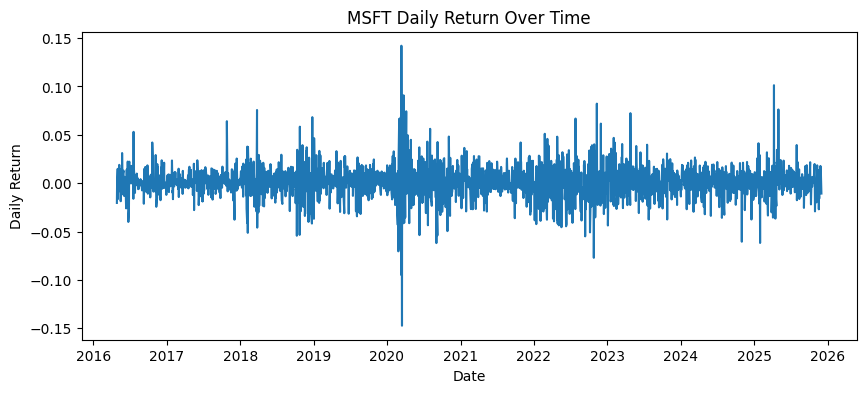

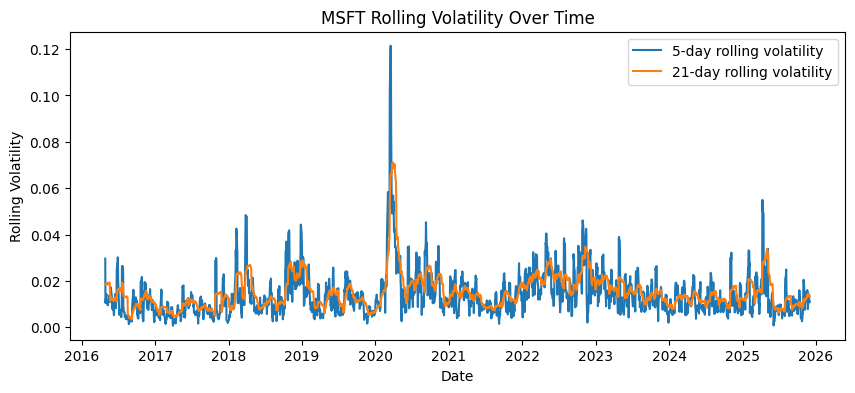

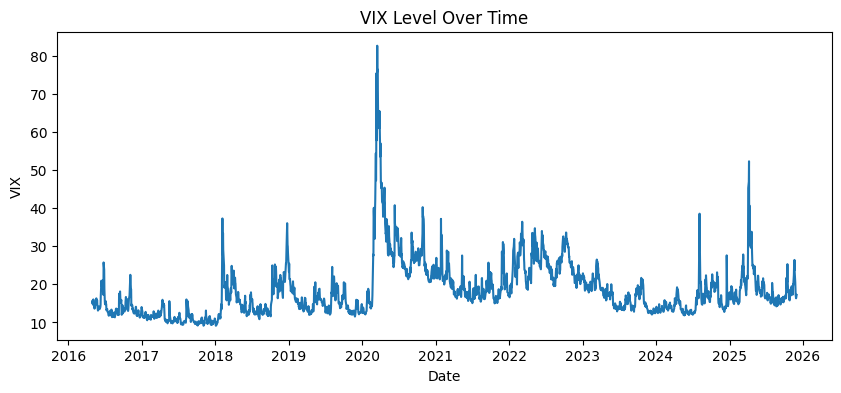

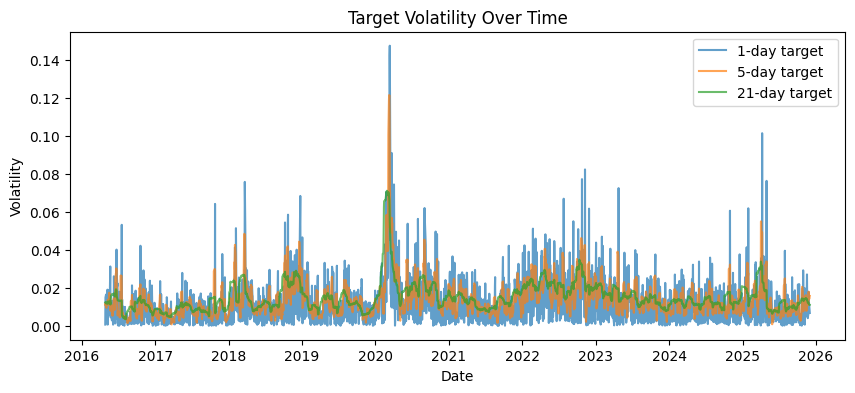

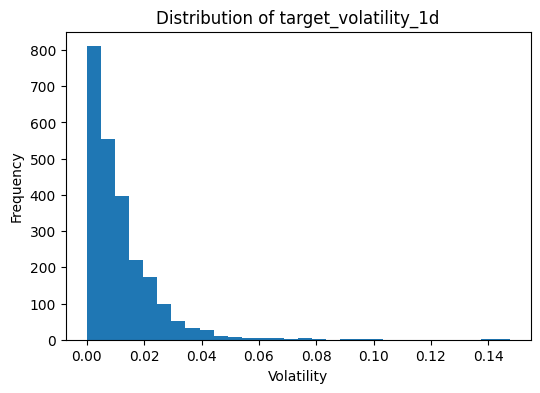

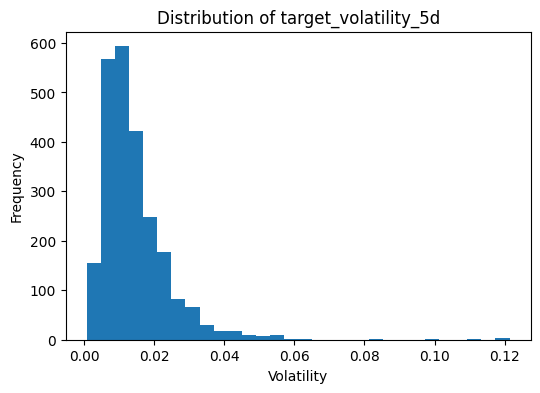

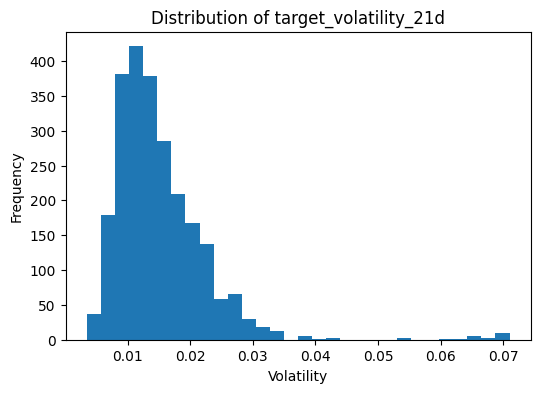

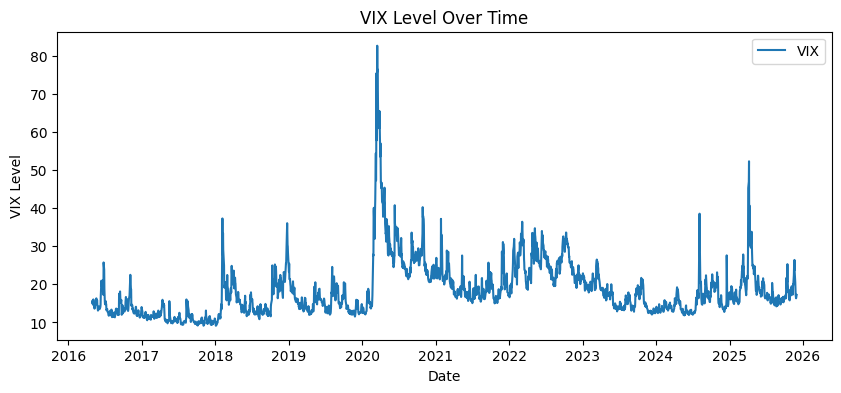

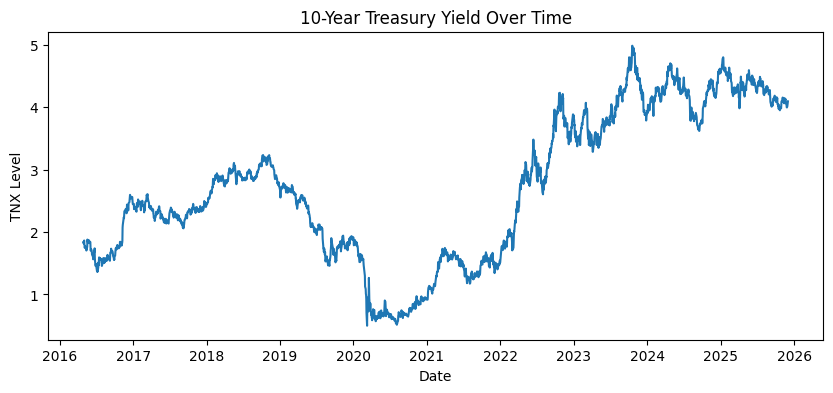

In [10]:
# Example visualization
# plt.figure(figsize=(6,4))
# df['your_column'].hist(bins=30)
# plt.title('Distribution of your_column')
# plt.show()

# 3.2 MSFT daily return over time

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['MSFT_return_1d'])
plt.title('MSFT Daily Return Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()


# 3.3 MSFT rolling volatility

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['MSFT_rolling_vol_5'], label='5-day rolling volatility')
plt.plot(model_data.index, model_data['MSFT_rolling_vol_21'], label='21-day rolling volatility')
plt.title('MSFT Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Rolling Volatility')
plt.legend()
plt.show()


# 3.4 VIX level over time

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['VIX_level'])
plt.title('VIX Level Over Time')
plt.xlabel('Date')
plt.ylabel('VIX')
plt.show()


# 3.5 Target variable summary

target_cols = [
    'target_volatility_1d',
    'target_volatility_5d',
    'target_volatility_21d'
]

model_data[target_cols].describe()


# 3.6 Target volatility over time

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['target_volatility_1d'], label='1-day target', alpha=0.7)
plt.plot(model_data.index, model_data['target_volatility_5d'], label='5-day target', alpha=0.7)
plt.plot(model_data.index, model_data['target_volatility_21d'], label='21-day target', alpha=0.7)
plt.title('Target Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()


# 3.7 Distribution of target variables

for col in target_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(model_data[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Volatility')
    plt.ylabel('Frequency')
    plt.show()


# 3.8 Additional market features over time

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['VIX_level'], label='VIX')
plt.title('VIX Level Over Time')
plt.xlabel('Date')
plt.ylabel('VIX Level')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['TNX_level'])
plt.title('10-Year Treasury Yield Over Time')
plt.xlabel('Date')
plt.ylabel('TNX Level')
plt.show()

# 4. Methodology

Clearly separate the problem description from the learning algorithms.

Include a separate subsection for hyperparameter tuning:
- Explain how tuning is performed.
- Make the comparison fair across models.
- State the validation procedure clearly.

## 4.1 Overview of Models
- You must try at least as many algorithms as group members.
- Each group member should implement at least one algorithm.
- Use models within the scope of the course.
- If using a more advanced model, provide sufficient background and compare it against standard baselines first.


## 4.2 Model 1: Support Vector Regression (SVR)

**Implemented by: Jenny Fu** 

- Motivation

Support Vector Regression (SVR) is chosen because future MSFT volatility may not have a simple linear relationship with the input features. Variables such as VIX, VXN, market returns, lagged MSFT returns, and rolling volatility may affect future volatility in a nonlinear way. Compared with linear regression, SVR can use a kernel function to fit a more flexible regression relationship.

SVR is also useful because financial data are noisy. It allows small prediction errors within an epsilon margin, and only penalizes errors outside that margin. This fits our task because small volatility prediction errors are acceptable, while larger errors should be penalized.

- Model description

Support Vector Regression is the regression version of SVM. Instead of separating classes, SVR fits a function to predict a continuous target:

f(x) = w^T x + b

A key idea is the epsilon-insensitive tube. If the prediction error is within ε, there is no penalty. If the error is larger than ε, the point is outside the tube and receives a penalty.

In this project, we use SVR with an RBF kernel to capture possible nonlinear relationships between market features and future MSFT volatility. The main parameters are C, ε, and gamma. C controls the penalty strength, ε controls the tube width, and gamma controls the flexibility of the RBF kernel.

- Why this method is appropriate/Key assumptions

SVR is appropriate because stock volatility may depend on nonlinear combinations of past returns, rolling volatility, market indexes, sector ETFs, and volatility indexes. It also works reasonably well for medium-sized datasets like our 10 years of daily stock data.

The main assumption is that past and current market information contains some signal about future volatility. We also split the data chronologically to avoid using future information. Since SVR is sensitive to feature scale, we standardize the features using only the training set and apply the same scaler to the validation and test sets.

In [11]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

param_grid = [
    {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 1, 'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 10, 'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 1, 'epsilon': 0.005, 'gamma': 'scale'},
    {'C': 10, 'epsilon': 0.005, 'gamma': 'scale'},
    {'C': 1, 'epsilon': 0.01, 'gamma': 'scale'},
    {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
]

In [12]:
# =========================
# SVR Model: 1-day volatility target
# =========================

y_train = y_train_1d
y_valid = y_valid_1d
y_test = y_test_1d

best_valid_rmse_1d = np.inf
best_svr_1d = None
best_params_1d = None
best_valid_pred_1d = None

for params in param_grid:
    svr = SVR(
        kernel='rbf',
        C=params['C'],
        epsilon=params['epsilon'],
        gamma=params['gamma']
    )
    
    # Train on training set
    svr.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = svr.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best hyperparameters using validation RMSE
    if valid_rmse < best_valid_rmse_1d:
        best_valid_rmse_1d = valid_rmse
        best_svr_1d = svr
        best_params_1d = params
        best_valid_pred_1d = y_valid_pred

print("Best parameters for 1-day target:", best_params_1d)
print("Best validation RMSE for 1-day target:", best_valid_rmse_1d)

# Validation metrics
valid_mae_1d = mean_absolute_error(y_valid, best_valid_pred_1d)
valid_rmse_1d = np.sqrt(mean_squared_error(y_valid, best_valid_pred_1d))
valid_r2_1d = r2_score(y_valid, best_valid_pred_1d)
valid_normalized_rmse_1d = valid_rmse_1d / np.std(y_valid)

# Test prediction using the selected best model
y_test_pred_1d = best_svr_1d.predict(X_test_scaled)

# Test metrics
test_mae_1d = mean_absolute_error(y_test, y_test_pred_1d)
test_rmse_1d = np.sqrt(mean_squared_error(y_test, y_test_pred_1d))
test_r2_1d = r2_score(y_test, y_test_pred_1d)
test_normalized_rmse_1d = test_rmse_1d / np.std(y_test)

# Naive baseline on test set
baseline_pred_1d = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_1d = np.sqrt(mean_squared_error(y_test, baseline_pred_1d))
improvement_1d = (baseline_rmse_1d - test_rmse_1d) / baseline_rmse_1d

print("\nSVR 1-day Validation Results")
print("Validation MAE:", valid_mae_1d)
print("Validation RMSE:", valid_rmse_1d)
print("Validation Normalized RMSE:", valid_normalized_rmse_1d)
print("Validation R2:", valid_r2_1d)

print("\nSVR 1-day Test Results")
print("Test MAE:", test_mae_1d)
print("Test RMSE:", test_rmse_1d)
print("Test Normalized RMSE:", test_normalized_rmse_1d)
print("Test R2:", test_r2_1d)
print("Baseline RMSE:", baseline_rmse_1d)
print("Improvement over baseline:", improvement_1d)

Best parameters for 1-day target: {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
Best validation RMSE for 1-day target: 0.01043976022860523

SVR 1-day Validation Results
Validation MAE: 0.00809832010354614
Validation RMSE: 0.01043976022860523
Validation Normalized RMSE: 1.1010028052738758
Validation R2: -0.21220717722094462

SVR 1-day Test Results
Test MAE: 0.008625628593285457
Test RMSE: 0.012033027562866653
Test Normalized RMSE: 1.1221199584136448
Test R2: -0.25915320107023776
Baseline RMSE: 0.01091169540203539
Improvement over baseline: -0.10276424694022315


In [13]:
# =========================
# SVR Model: 5-day volatility target
# =========================

y_train = y_train_5d
y_valid = y_valid_5d
y_test = y_test_5d

best_valid_rmse_5d = np.inf
best_svr_5d = None
best_params_5d = None
best_valid_pred_5d = None

for params in param_grid:
    svr = SVR(
        kernel='rbf',
        C=params['C'],
        epsilon=params['epsilon'],
        gamma=params['gamma']
    )
    
    # Train on training set
    svr.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = svr.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best hyperparameters using validation RMSE
    if valid_rmse < best_valid_rmse_5d:
        best_valid_rmse_5d = valid_rmse
        best_svr_5d = svr
        best_params_5d = params
        best_valid_pred_5d = y_valid_pred

print("Best parameters for 5-day target:", best_params_5d)
print("Best validation RMSE for 5-day target:", best_valid_rmse_5d)

# Validation metrics
valid_mae_5d = mean_absolute_error(y_valid, best_valid_pred_5d)
valid_rmse_5d = np.sqrt(mean_squared_error(y_valid, best_valid_pred_5d))
valid_r2_5d = r2_score(y_valid, best_valid_pred_5d)
valid_normalized_rmse_5d = valid_rmse_5d / np.std(y_valid)

# Test prediction using the selected best model
y_test_pred_5d = best_svr_5d.predict(X_test_scaled)

# Test metrics
test_mae_5d = mean_absolute_error(y_test, y_test_pred_5d)
test_rmse_5d = np.sqrt(mean_squared_error(y_test, y_test_pred_5d))
test_r2_5d = r2_score(y_test, y_test_pred_5d)
test_normalized_rmse_5d = test_rmse_5d / np.std(y_test)

# Naive baseline on test set
baseline_pred_5d = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_5d = np.sqrt(mean_squared_error(y_test, baseline_pred_5d))
improvement_5d = (baseline_rmse_5d - test_rmse_5d) / baseline_rmse_5d

print("\nSVR 5-day Validation Results")
print("Validation MAE:", valid_mae_5d)
print("Validation RMSE:", valid_rmse_5d)
print("Validation Normalized RMSE:", valid_normalized_rmse_5d)
print("Validation R2:", valid_r2_5d)

print("\nSVR 5-day Test Results")
print("Test MAE:", test_mae_5d)
print("Test RMSE:", test_rmse_5d)
print("Test Normalized RMSE:", test_normalized_rmse_5d)
print("Test R2:", test_r2_5d)
print("Baseline RMSE:", baseline_rmse_5d)
print("Improvement over baseline:", improvement_5d)

Best parameters for 5-day target: {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
Best validation RMSE for 5-day target: 0.008155006862656924

SVR 5-day Validation Results
Validation MAE: 0.006452115289122921
Validation RMSE: 0.008155006862656924
Validation Normalized RMSE: 1.3261481928764742
Validation R2: -0.7586690294695382

SVR 5-day Test Results
Test MAE: 0.007632076563881472
Test RMSE: 0.0095434420165587
Test Normalized RMSE: 1.2346707020243062
Test R2: -0.5244117424371924
Baseline RMSE: 0.008021296085889437
Improvement over baseline: -0.189763089950878


In [14]:
# =========================
# SVR Model: 21-day volatility target
# =========================

y_train = y_train_21d
y_valid = y_valid_21d
y_test = y_test_21d

best_valid_rmse_21d = np.inf
best_svr_21d = None
best_params_21d = None
best_valid_pred_21d = None

for params in param_grid:
    svr = SVR(
        kernel='rbf',
        C=params['C'],
        epsilon=params['epsilon'],
        gamma=params['gamma']
    )
    
    # Train on training set
    svr.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = svr.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best hyperparameters using validation RMSE
    if valid_rmse < best_valid_rmse_21d:
        best_valid_rmse_21d = valid_rmse
        best_svr_21d = svr
        best_params_21d = params
        best_valid_pred_21d = y_valid_pred

print("Best parameters for 21-day target:", best_params_21d)
print("Best validation RMSE for 21-day target:", best_valid_rmse_21d)

# Validation metrics
valid_mae_21d = mean_absolute_error(y_valid, best_valid_pred_21d)
valid_rmse_21d = np.sqrt(mean_squared_error(y_valid, best_valid_pred_21d))
valid_r2_21d = r2_score(y_valid, best_valid_pred_21d)
valid_normalized_rmse_21d = valid_rmse_21d / np.std(y_valid)

# Test prediction using the selected best model
y_test_pred_21d = best_svr_21d.predict(X_test_scaled)

# Test metrics
test_mae_21d = mean_absolute_error(y_test, y_test_pred_21d)
test_rmse_21d = np.sqrt(mean_squared_error(y_test, y_test_pred_21d))
test_r2_21d = r2_score(y_test, y_test_pred_21d)
test_normalized_rmse_21d = test_rmse_21d / np.std(y_test)

# Naive baseline on test set
baseline_pred_21d = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_21d = np.sqrt(mean_squared_error(y_test, baseline_pred_21d))
improvement_21d = (baseline_rmse_21d - test_rmse_21d) / baseline_rmse_21d

print("\nSVR 21-day Validation Results")
print("Validation MAE:", valid_mae_21d)
print("Validation RMSE:", valid_rmse_21d)
print("Validation Normalized RMSE:", valid_normalized_rmse_21d)
print("Validation R2:", valid_r2_21d)

print("\nSVR 21-day Test Results")
print("Test MAE:", test_mae_21d)
print("Test RMSE:", test_rmse_21d)
print("Test Normalized RMSE:", test_normalized_rmse_21d)
print("Test R2:", test_r2_21d)
print("Baseline RMSE:", baseline_rmse_21d)
print("Improvement over baseline:", improvement_21d)

Best parameters for 21-day target: {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
Best validation RMSE for 21-day target: 0.00760939699755472

SVR 21-day Validation Results
Validation MAE: 0.006280213728222544
Validation RMSE: 0.00760939699755472
Validation Normalized RMSE: 2.2865714830542587
Validation R2: -4.228409147116955

SVR 21-day Test Results
Test MAE: 0.005347898620564217
Test RMSE: 0.006601190078698491
Test Normalized RMSE: 1.2378465317088463
Test R2: -0.5322640360636202
Baseline RMSE: 0.0056824967871779404
Improvement over baseline: -0.16167071024017157


In [15]:
# =========================
# SVR Summary Table
# =========================

svr_summary = pd.DataFrame({
    "Target": [
        "1-day volatility",
        "5-day volatility",
        "21-day volatility"
    ],
    
    "Best Parameters": [
        best_params_1d,
        best_params_5d,
        best_params_21d
    ],
    
    "Validation RMSE": [
        valid_rmse_1d,
        valid_rmse_5d,
        valid_rmse_21d
    ],
    
    "Validation Normalized RMSE": [
        valid_normalized_rmse_1d,
        valid_normalized_rmse_5d,
        valid_normalized_rmse_21d
    ],
    
    "Test MAE": [
        test_mae_1d,
        test_mae_5d,
        test_mae_21d
    ],
    
    "Test RMSE": [
        test_rmse_1d,
        test_rmse_5d,
        test_rmse_21d
    ],
    
    "Test Normalized RMSE": [
        test_normalized_rmse_1d,
        test_normalized_rmse_5d,
        test_normalized_rmse_21d
    ],
    
    "Test R2": [
        test_r2_1d,
        test_r2_5d,
        test_r2_21d
    ],
    
    "Baseline RMSE": [
        baseline_rmse_1d,
        baseline_rmse_5d,
        baseline_rmse_21d
    ],
    
    "Improvement over Baseline": [
        improvement_1d,
        improvement_5d,
        improvement_21d
    ]
})

svr_summary_rounded = svr_summary.copy()

numeric_cols = [
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Test MAE",
    "Test RMSE",
    "Test Normalized RMSE",
    "Test R2",
    "Baseline RMSE",
    "Improvement over Baseline"
]

svr_summary_rounded[numeric_cols] = svr_summary_rounded[numeric_cols].round(4)

svr_summary_rounded

,Target,Best Parameters,Validation RMSE,Validation Normalized RMSE,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,"{'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}",0.0104,1.1010,0.0086,0.0120,1.1221,-0.2592,0.0109,-0.1028
1,5-day volatility,"{'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}",0.0082,1.3261,0.0076,0.0095,1.2347,-0.5244,0.0080,-0.1898
2,21-day volatility,"{'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}",0.0076,2.2866,0.0053,0.0066,1.2378,-0.5323,0.0057,-0.1617


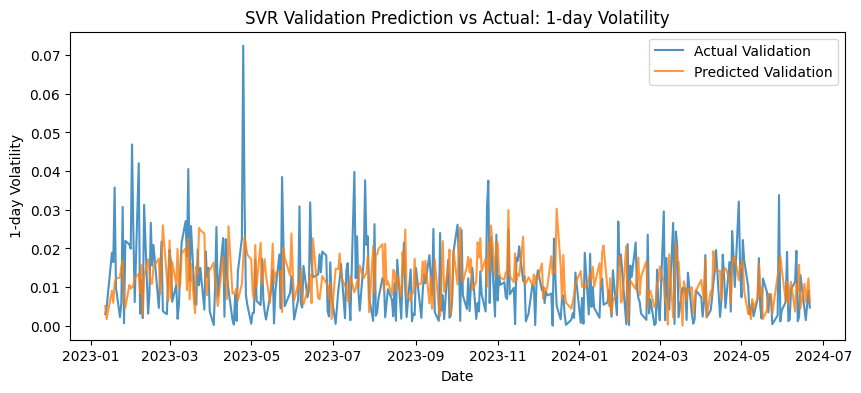

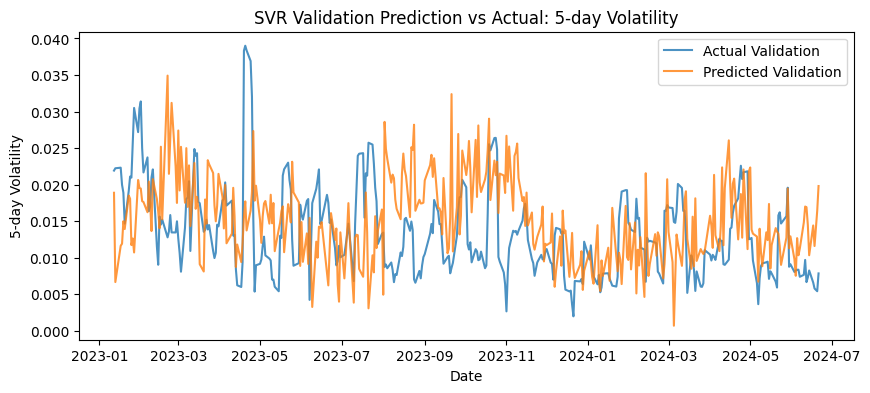

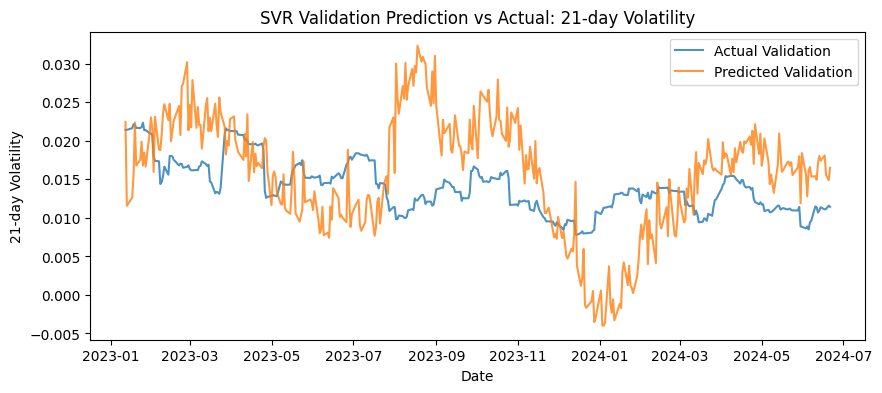

In [16]:
# =========================
# SVR Validation Prediction vs Actual Plots
# =========================

plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_1d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_1d, label='Predicted Validation', alpha=0.8)
plt.title('SVR Validation Prediction vs Actual: 1-day Volatility')
plt.xlabel('Date')
plt.ylabel('1-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_5d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_5d, label='Predicted Validation', alpha=0.8)
plt.title('SVR Validation Prediction vs Actual: 5-day Volatility')
plt.xlabel('Date')
plt.ylabel('5-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_21d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_21d, label='Predicted Validation', alpha=0.8)
plt.title('SVR Validation Prediction vs Actual: 21-day Volatility')
plt.xlabel('Date')
plt.ylabel('21-day Volatility')
plt.legend()
plt.show()

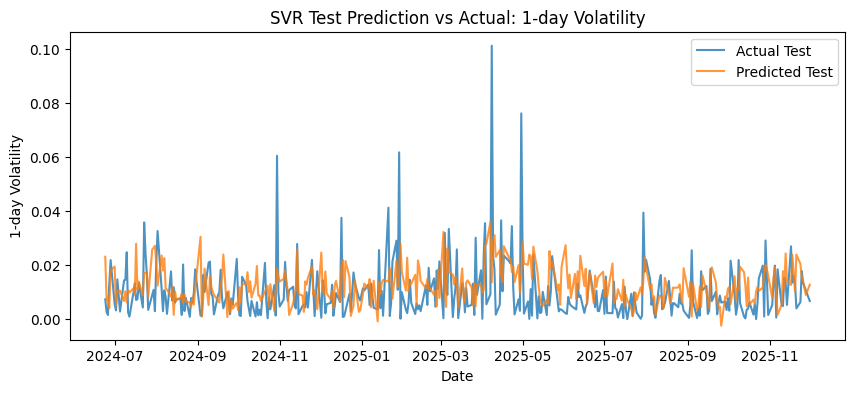

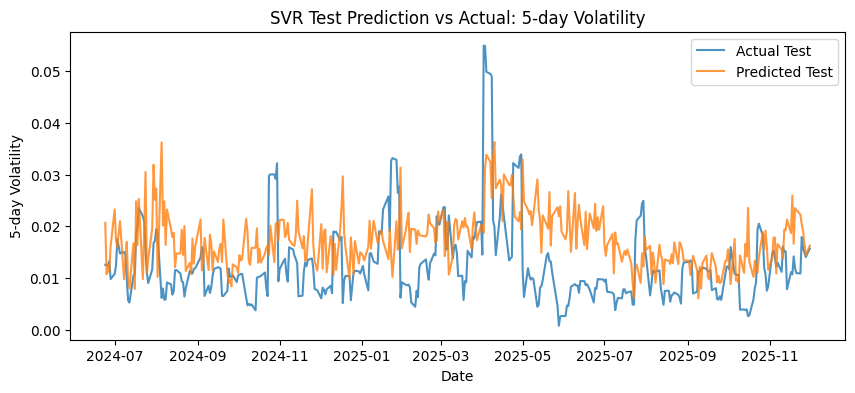

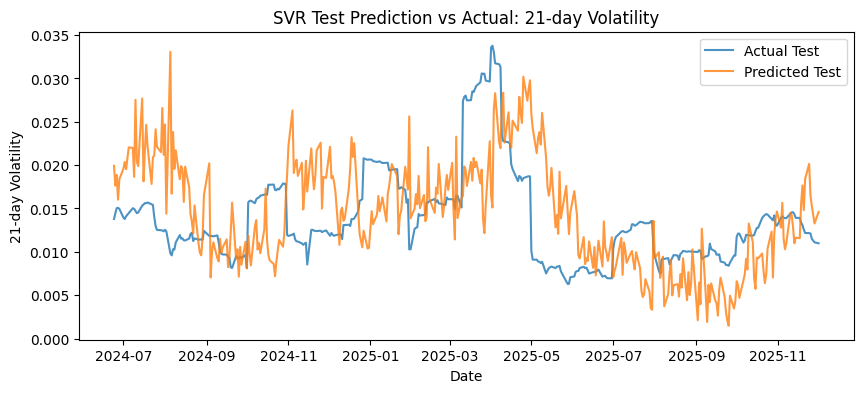

In [17]:
# =========================
# SVR Test Prediction vs Actual Plots
# =========================

plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_1d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_1d, label='Predicted Test', alpha=0.8)
plt.title('SVR Test Prediction vs Actual: 1-day Volatility')
plt.xlabel('Date')
plt.ylabel('1-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_5d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_5d, label='Predicted Test', alpha=0.8)
plt.title('SVR Test Prediction vs Actual: 5-day Volatility')
plt.xlabel('Date')
plt.ylabel('5-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_21d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_21d, label='Predicted Test', alpha=0.8)
plt.title('SVR Test Prediction vs Actual: 21-day Volatility')
plt.xlabel('Date')
plt.ylabel('21-day Volatility')
plt.legend()
plt.show()

In [18]:
# =========================
# Lasso Regression Model
# =========================

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

alpha_grid = [
    0.00001,
    0.00005,
    0.0001,
    0.0005,
    0.001,
    0.005,
    0.01,
    0.05,
    0.1
]

In [19]:
# =========================
# Lasso Model: 1-day volatility target
# =========================

y_train = y_train_1d
y_valid = y_valid_1d
y_test = y_test_1d

best_valid_rmse_1d_lasso = np.inf
best_lasso_1d = None
best_alpha_1d = None
best_valid_pred_1d_lasso = None

for alpha in alpha_grid:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    
    # Train on training set
    lasso.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = lasso.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best alpha using validation RMSE
    if valid_rmse < best_valid_rmse_1d_lasso:
        best_valid_rmse_1d_lasso = valid_rmse
        best_lasso_1d = lasso
        best_alpha_1d = alpha
        best_valid_pred_1d_lasso = y_valid_pred

print("Best alpha for 1-day target:", best_alpha_1d)
print("Best validation RMSE for 1-day target:", best_valid_rmse_1d_lasso)

# Validation metrics
valid_mae_1d_lasso = mean_absolute_error(y_valid, best_valid_pred_1d_lasso)
valid_rmse_1d_lasso = np.sqrt(mean_squared_error(y_valid, best_valid_pred_1d_lasso))
valid_r2_1d_lasso = r2_score(y_valid, best_valid_pred_1d_lasso)
valid_normalized_rmse_1d_lasso = valid_rmse_1d_lasso / np.std(y_valid)

# Test prediction
y_test_pred_1d_lasso = best_lasso_1d.predict(X_test_scaled)

# Test metrics
test_mae_1d_lasso = mean_absolute_error(y_test, y_test_pred_1d_lasso)
test_rmse_1d_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_1d_lasso))
test_r2_1d_lasso = r2_score(y_test, y_test_pred_1d_lasso)
test_normalized_rmse_1d_lasso = test_rmse_1d_lasso / np.std(y_test)

# Naive baseline on test set
baseline_pred_1d_lasso = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_1d_lasso = np.sqrt(mean_squared_error(y_test, baseline_pred_1d_lasso))
improvement_1d_lasso = (baseline_rmse_1d_lasso - test_rmse_1d_lasso) / baseline_rmse_1d_lasso

print("\nLasso 1-day Validation Results")
print("Validation MAE:", valid_mae_1d_lasso)
print("Validation RMSE:", valid_rmse_1d_lasso)
print("Validation Normalized RMSE:", valid_normalized_rmse_1d_lasso)
print("Validation R2:", valid_r2_1d_lasso)

print("\nLasso 1-day Test Results")
print("Test MAE:", test_mae_1d_lasso)
print("Test RMSE:", test_rmse_1d_lasso)
print("Test Normalized RMSE:", test_normalized_rmse_1d_lasso)
print("Test R2:", test_r2_1d_lasso)
print("Baseline RMSE:", baseline_rmse_1d_lasso)
print("Improvement over baseline:", improvement_1d_lasso)

Best alpha for 1-day target: 0.0005
Best validation RMSE for 1-day target: 0.00913042716887686

Lasso 1-day Validation Results
Validation MAE: 0.0069908596396560585
Validation RMSE: 0.00913042716887686
Validation Normalized RMSE: 0.9629173186121426
Validation R2: 0.07279023751680136

Lasso 1-day Test Results
Test MAE: 0.007512664633119623
Test RMSE: 0.010498500833162276
Test Normalized RMSE: 0.9790202221981079
Test R2: 0.04151940452716896
Baseline RMSE: 0.01091169540203539
Improvement over baseline: 0.03786712821877704


In [20]:
# =========================
# Lasso Model: 5-day volatility target
# =========================

y_train = y_train_5d
y_valid = y_valid_5d
y_test = y_test_5d

best_valid_rmse_5d_lasso = np.inf
best_lasso_5d = None
best_alpha_5d = None
best_valid_pred_5d_lasso = None

for alpha in alpha_grid:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    
    # Train on training set
    lasso.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = lasso.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best alpha using validation RMSE
    if valid_rmse < best_valid_rmse_5d_lasso:
        best_valid_rmse_5d_lasso = valid_rmse
        best_lasso_5d = lasso
        best_alpha_5d = alpha
        best_valid_pred_5d_lasso = y_valid_pred

print("Best alpha for 5-day target:", best_alpha_5d)
print("Best validation RMSE for 5-day target:", best_valid_rmse_5d_lasso)

# Validation metrics
valid_mae_5d_lasso = mean_absolute_error(y_valid, best_valid_pred_5d_lasso)
valid_rmse_5d_lasso = np.sqrt(mean_squared_error(y_valid, best_valid_pred_5d_lasso))
valid_r2_5d_lasso = r2_score(y_valid, best_valid_pred_5d_lasso)
valid_normalized_rmse_5d_lasso = valid_rmse_5d_lasso / np.std(y_valid)

# Test prediction
y_test_pred_5d_lasso = best_lasso_5d.predict(X_test_scaled)

# Test metrics
test_mae_5d_lasso = mean_absolute_error(y_test, y_test_pred_5d_lasso)
test_rmse_5d_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_5d_lasso))
test_r2_5d_lasso = r2_score(y_test, y_test_pred_5d_lasso)
test_normalized_rmse_5d_lasso = test_rmse_5d_lasso / np.std(y_test)

# Naive baseline on test set
baseline_pred_5d_lasso = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_5d_lasso = np.sqrt(mean_squared_error(y_test, baseline_pred_5d_lasso))
improvement_5d_lasso = (baseline_rmse_5d_lasso - test_rmse_5d_lasso) / baseline_rmse_5d_lasso

print("\nLasso 5-day Validation Results")
print("Validation MAE:", valid_mae_5d_lasso)
print("Validation RMSE:", valid_rmse_5d_lasso)
print("Validation Normalized RMSE:", valid_normalized_rmse_5d_lasso)
print("Validation R2:", valid_r2_5d_lasso)

print("\nLasso 5-day Test Results")
print("Test MAE:", test_mae_5d_lasso)
print("Test RMSE:", test_rmse_5d_lasso)
print("Test Normalized RMSE:", test_normalized_rmse_5d_lasso)
print("Test R2:", test_r2_5d_lasso)
print("Baseline RMSE:", baseline_rmse_5d_lasso)
print("Improvement over baseline:", improvement_5d_lasso)

Best alpha for 5-day target: 0.001
Best validation RMSE for 5-day target: 0.005801024940610563

Lasso 5-day Validation Results
Validation MAE: 0.004364095807230912
Validation RMSE: 0.005801024940610563
Validation Normalized RMSE: 0.9433491438308425
Validation R2: 0.11009239283361683

Lasso 5-day Test Results
Test MAE: 0.0054358442868984455
Test RMSE: 0.007282634235978321
Test Normalized RMSE: 0.9421815639598689
Test R2: 0.11229390053413602
Baseline RMSE: 0.008021296085889437
Improvement over baseline: 0.09208759307744842


In [21]:
# =========================
# Lasso Model: 21-day volatility target
# =========================

y_train = y_train_21d
y_valid = y_valid_21d
y_test = y_test_21d

best_valid_rmse_21d_lasso = np.inf
best_lasso_21d = None
best_alpha_21d = None
best_valid_pred_21d_lasso = None

for alpha in alpha_grid:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    
    # Train on training set
    lasso.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = lasso.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best alpha using validation RMSE
    if valid_rmse < best_valid_rmse_21d_lasso:
        best_valid_rmse_21d_lasso = valid_rmse
        best_lasso_21d = lasso
        best_alpha_21d = alpha
        best_valid_pred_21d_lasso = y_valid_pred

print("Best alpha for 21-day target:", best_alpha_21d)
print("Best validation RMSE for 21-day target:", best_valid_rmse_21d_lasso)

# Validation metrics
valid_mae_21d_lasso = mean_absolute_error(y_valid, best_valid_pred_21d_lasso)
valid_rmse_21d_lasso = np.sqrt(mean_squared_error(y_valid, best_valid_pred_21d_lasso))
valid_r2_21d_lasso = r2_score(y_valid, best_valid_pred_21d_lasso)
valid_normalized_rmse_21d_lasso = valid_rmse_21d_lasso / np.std(y_valid)

# Test prediction
y_test_pred_21d_lasso = best_lasso_21d.predict(X_test_scaled)

# Test metrics
test_mae_21d_lasso = mean_absolute_error(y_test, y_test_pred_21d_lasso)
test_rmse_21d_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_21d_lasso))
test_r2_21d_lasso = r2_score(y_test, y_test_pred_21d_lasso)
test_normalized_rmse_21d_lasso = test_rmse_21d_lasso / np.std(y_test)

# Naive baseline on test set
baseline_pred_21d_lasso = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_21d_lasso = np.sqrt(mean_squared_error(y_test, baseline_pred_21d_lasso))
improvement_21d_lasso = (baseline_rmse_21d_lasso - test_rmse_21d_lasso) / baseline_rmse_21d_lasso

print("\nLasso 21-day Validation Results")
print("Validation MAE:", valid_mae_21d_lasso)
print("Validation RMSE:", valid_rmse_21d_lasso)
print("Validation Normalized RMSE:", valid_normalized_rmse_21d_lasso)
print("Validation R2:", valid_r2_21d_lasso)

print("\nLasso 21-day Test Results")
print("Test MAE:", test_mae_21d_lasso)
print("Test RMSE:", test_rmse_21d_lasso)
print("Test Normalized RMSE:", test_normalized_rmse_21d_lasso)
print("Test R2:", test_r2_21d_lasso)
print("Baseline RMSE:", baseline_rmse_21d_lasso)
print("Improvement over baseline:", improvement_21d_lasso)

Best alpha for 21-day target: 0.001
Best validation RMSE for 21-day target: 0.0028575827266771646

Lasso 21-day Validation Results
Validation MAE: 0.002267579491394638
Validation RMSE: 0.0028575827266771646
Validation Normalized RMSE: 0.858683963445219
Validation R2: 0.2626618509220092

Lasso 21-day Test Results
Test MAE: 0.0038213699012294793
Test RMSE: 0.005039754123007909
Test Normalized RMSE: 0.9450481030627567
Test R2: 0.10688408289748519
Baseline RMSE: 0.0056824967871779404
Improvement over baseline: 0.11310919974830859


In [22]:
# =========================
# Lasso Summary Table
# =========================

lasso_summary = pd.DataFrame({
    "Target": [
        "1-day volatility",
        "5-day volatility",
        "21-day volatility"
    ],
    
    "Best Alpha": [
        best_alpha_1d,
        best_alpha_5d,
        best_alpha_21d
    ],
    
    "Validation RMSE": [
        valid_rmse_1d_lasso,
        valid_rmse_5d_lasso,
        valid_rmse_21d_lasso
    ],
    
    "Validation Normalized RMSE": [
        valid_normalized_rmse_1d_lasso,
        valid_normalized_rmse_5d_lasso,
        valid_normalized_rmse_21d_lasso
    ],
    
    "Test MAE": [
        test_mae_1d_lasso,
        test_mae_5d_lasso,
        test_mae_21d_lasso
    ],
    
    "Test RMSE": [
        test_rmse_1d_lasso,
        test_rmse_5d_lasso,
        test_rmse_21d_lasso
    ],
    
    "Test Normalized RMSE": [
        test_normalized_rmse_1d_lasso,
        test_normalized_rmse_5d_lasso,
        test_normalized_rmse_21d_lasso
    ],
    
    "Test R2": [
        test_r2_1d_lasso,
        test_r2_5d_lasso,
        test_r2_21d_lasso
    ],
    
    "Baseline RMSE": [
        baseline_rmse_1d_lasso,
        baseline_rmse_5d_lasso,
        baseline_rmse_21d_lasso
    ],
    
    "Improvement over Baseline": [
        improvement_1d_lasso,
        improvement_5d_lasso,
        improvement_21d_lasso
    ]
})

lasso_summary_rounded = lasso_summary.copy()

numeric_cols = [
    "Best Alpha",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Test MAE",
    "Test RMSE",
    "Test Normalized RMSE",
    "Test R2",
    "Baseline RMSE",
    "Improvement over Baseline"
]

lasso_summary_rounded[numeric_cols] = lasso_summary_rounded[numeric_cols].round(4)

lasso_summary_rounded

,Target,Best Alpha,Validation RMSE,Validation Normalized RMSE,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,0.0005,0.0091,0.9629,0.0075,0.0105,0.9790,0.0415,0.0109,0.0379
1,5-day volatility,0.0010,0.0058,0.9433,0.0054,0.0073,0.9422,0.1123,0.0080,0.0921
2,21-day volatility,0.0010,0.0029,0.8587,0.0038,0.0050,0.9450,0.1069,0.0057,0.1131


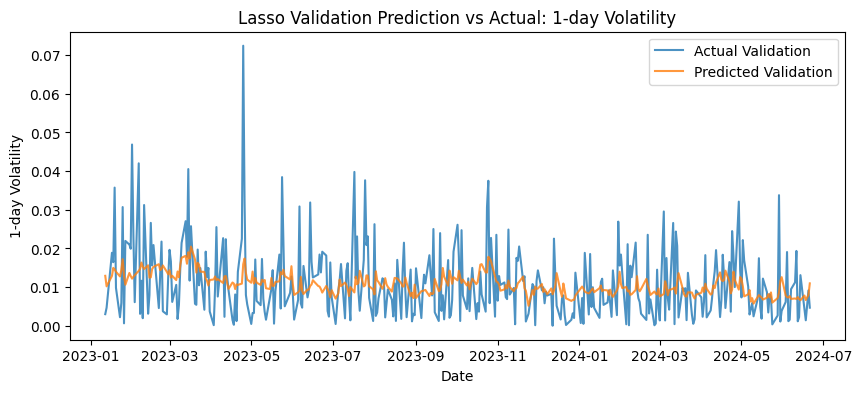

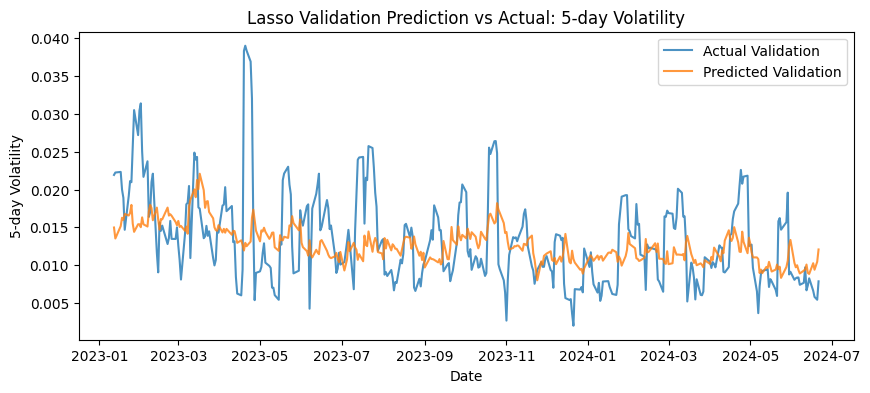

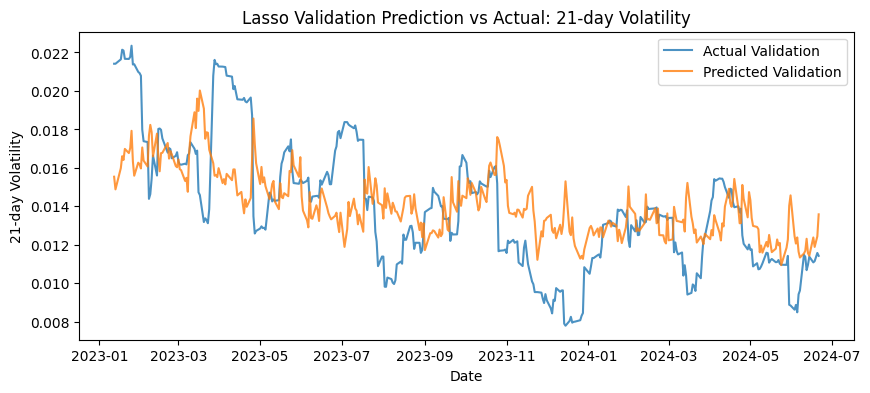

In [23]:
# =========================
# Lasso Validation Prediction vs Actual Plots
# =========================

plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_1d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_1d_lasso, label='Predicted Validation', alpha=0.8)
plt.title('Lasso Validation Prediction vs Actual: 1-day Volatility')
plt.xlabel('Date')
plt.ylabel('1-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_5d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_5d_lasso, label='Predicted Validation', alpha=0.8)
plt.title('Lasso Validation Prediction vs Actual: 5-day Volatility')
plt.xlabel('Date')
plt.ylabel('5-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_21d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_21d_lasso, label='Predicted Validation', alpha=0.8)
plt.title('Lasso Validation Prediction vs Actual: 21-day Volatility')
plt.xlabel('Date')
plt.ylabel('21-day Volatility')
plt.legend()
plt.show()

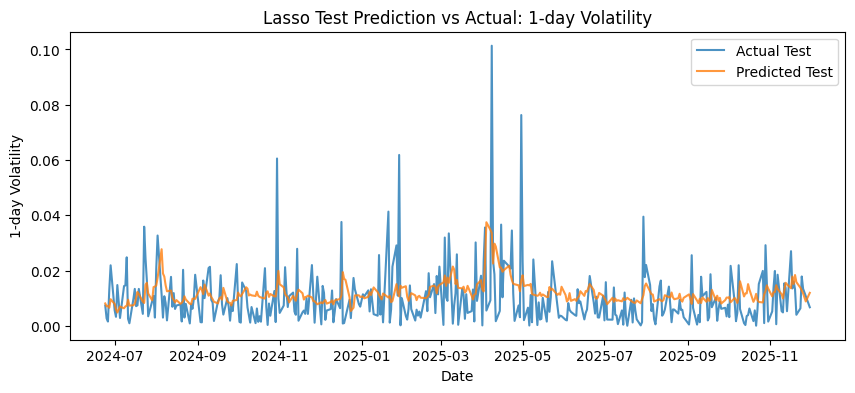

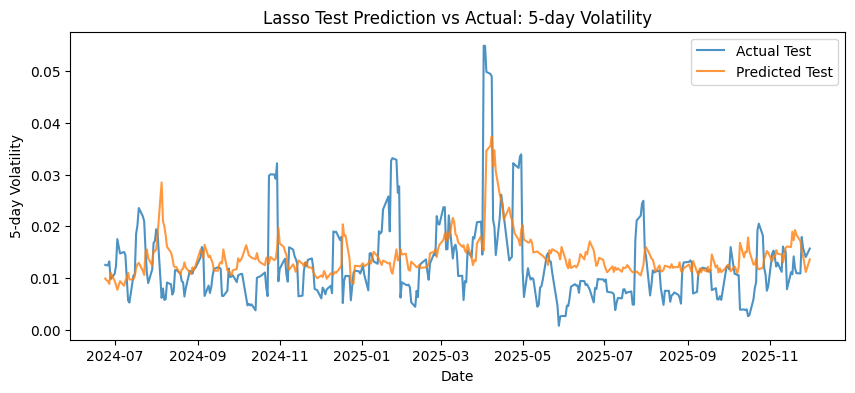

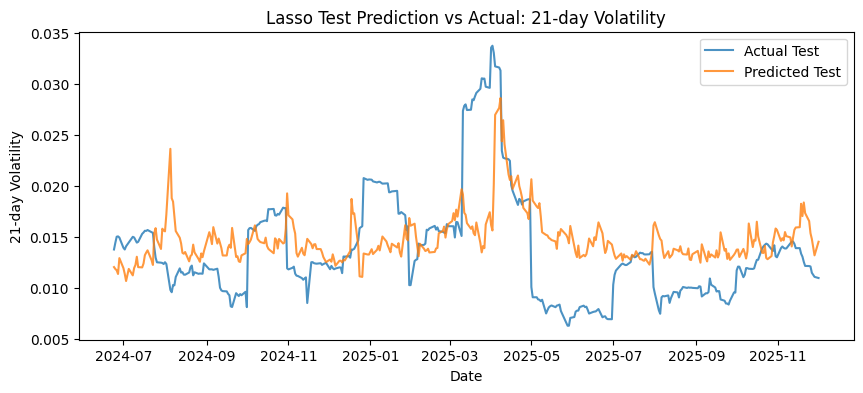

In [24]:
# =========================
# Lasso Test Prediction vs Actual Plots
# =========================

plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_1d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_1d_lasso, label='Predicted Test', alpha=0.8)
plt.title('Lasso Test Prediction vs Actual: 1-day Volatility')
plt.xlabel('Date')
plt.ylabel('1-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_5d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_5d_lasso, label='Predicted Test', alpha=0.8)
plt.title('Lasso Test Prediction vs Actual: 5-day Volatility')
plt.xlabel('Date')
plt.ylabel('5-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_21d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_21d_lasso, label='Predicted Test', alpha=0.8)
plt.title('Lasso Test Prediction vs Actual: 21-day Volatility')
plt.xlabel('Date')
plt.ylabel('21-day Volatility')
plt.legend()
plt.show()

## 4.3 Model 2: Gradient Boost

**Implemented by: Emma Xu** 

- Motivation

    Gradient Boosting is used because stock volatility is likely driven by nonlinear relationships among market variables. For example, the effect of VIX on MSFT volatility may become stronger during high-volatility periods, and recent MSFT volatility may interact with market-wide volatility measures such as SPY and XLK rolling volatility. A simple linear model may not fully capture these nonlinear patterns.

- Model description

    Gradient Boosting is an ensemble learning method that builds many decision trees sequentially. Each new tree is trained to correct the prediction errors made by the previous trees. Instead of fitting one large tree, the model combines many small trees to gradually improve prediction accuracy.

- Why this method is appropriate

    This method is appropriate for volatility prediction because financial volatility often has nonlinear behavior, volatility clustering, and interactions between stock-specific and market-wide variables. Gradient Boosting can capture these complex patterns without requiring us to manually specify nonlinear terms.


Repeat until Model N (N=your group size)

Best Gradient Boosting validation performance:


,Horizon,n_estimators,learning_rate,max_depth,Validation MAE,Validation RMSE,Validation Normalized MAE,Validation R2
0,Daily 1D,50,0.03,2,0.007029,0.009199,0.636827,0.058901
1,Weekly 5D,50,0.01,2,0.004598,0.005872,0.341315,0.088096
2,Monthly 21D,50,0.01,2,0.003074,0.003651,0.220919,-0.203495


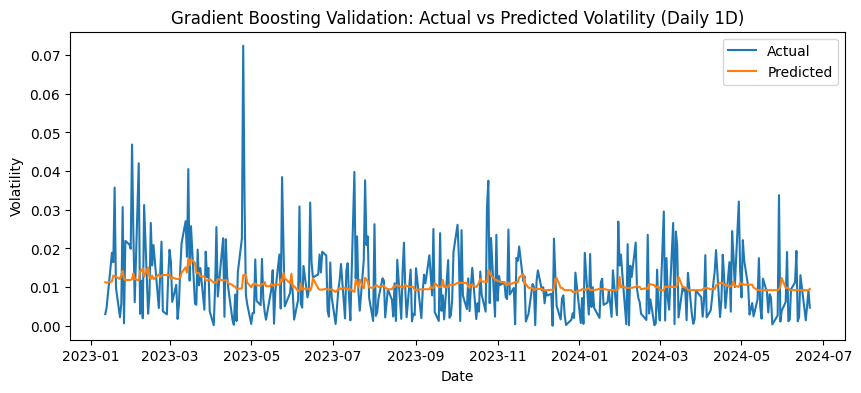

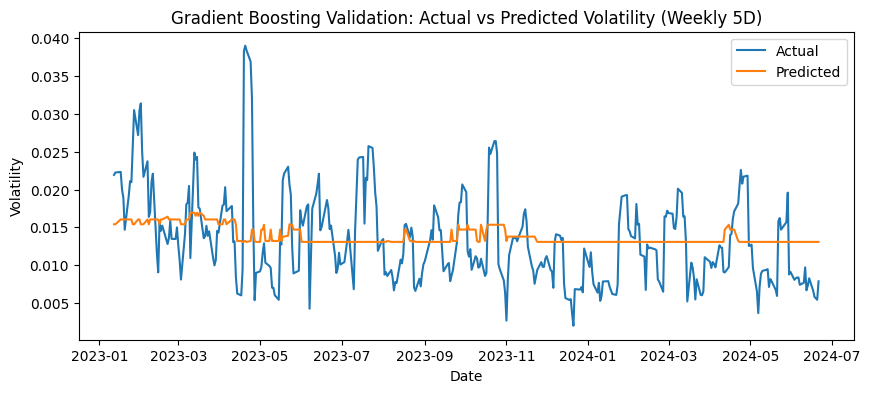

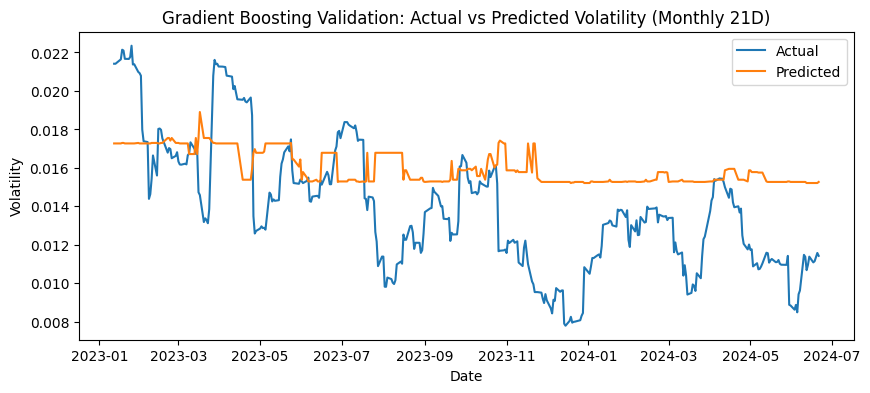

In [25]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

horizon_order = ['Daily 1D', 'Weekly 5D', 'Monthly 21D']

# Targets for validation tuning
targets = {
    'Daily 1D': (y_train_1d, y_valid_1d),
    'Weekly 5D': (y_train_5d, y_valid_5d),
    'Monthly 21D': (y_train_21d, y_valid_21d)
}

# Candidate hyperparameters
param_grid = [
    {'n_estimators': 50, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 50, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 2},
]

tuning_results = []

for horizon in horizon_order:
    
    y_train, y_valid = targets[horizon]
    
    for params in param_grid:
        
        model = GradientBoostingRegressor(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            random_state=42
        )
        
        # Train on training set only
        model.fit(X_train_scaled, y_train)
        
        # Predict on validation set only
        y_valid_pred = model.predict(X_valid_scaled)
        
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_mae = valid_mae / y_valid.mean()
        
        tuning_results.append({
            'Horizon': horizon,
            'n_estimators': params['n_estimators'],
            'learning_rate': params['learning_rate'],
            'max_depth': params['max_depth'],
            'Validation MAE': valid_mae,
            'Validation RMSE': valid_rmse,
            'Validation Normalized MAE': valid_normalized_mae,
            'Validation R2': valid_r2
        })

tuning_results_df = pd.DataFrame(tuning_results)

# Sort full tuning table by horizon and normalized MAE
tuning_results_df['Horizon'] = pd.Categorical(
    tuning_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

tuning_results_df = (
    tuning_results_df
    .sort_values(['Horizon', 'Validation Normalized MAE'])
    .reset_index(drop=True)
)

tuning_results_df

# Select best parameters for each horizon
best_params_by_horizon = (
    tuning_results_df
    .sort_values('Validation Normalized MAE')
    .groupby('Horizon', observed=True)
    .first()
    .reset_index()
)

best_params_by_horizon['Horizon'] = pd.Categorical(
    best_params_by_horizon['Horizon'],
    categories=horizon_order,
    ordered=True
)

best_params_by_horizon = (
    best_params_by_horizon
    .sort_values('Horizon')
    .reset_index(drop=True)
)


# Refit best Gradient Boosting models and plot validation predictions
best_gb_models = {}
best_gb_valid_predictions = {}
best_gb_valid_results = []

for _, row in best_params_by_horizon.iterrows():
    
    horizon = row['Horizon']
    y_train, y_valid = targets[horizon]
    
    model = GradientBoostingRegressor(
        n_estimators=int(row['n_estimators']),
        learning_rate=float(row['learning_rate']),
        max_depth=int(row['max_depth']),
        random_state=42
    )
    
    # Train on training set only
    model.fit(X_train_scaled, y_train)
    
    # Predict on validation set
    y_valid_pred = model.predict(X_valid_scaled)
    
    # Validation metrics
    valid_mae = mean_absolute_error(y_valid, y_valid_pred)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    valid_r2 = r2_score(y_valid, y_valid_pred)
    valid_normalized_mae = valid_mae / y_valid.mean()
    
    best_gb_valid_results.append({
        'Horizon': horizon,
        'n_estimators': int(row['n_estimators']),
        'learning_rate': float(row['learning_rate']),
        'max_depth': int(row['max_depth']),
        'Validation MAE': valid_mae,
        'Validation RMSE': valid_rmse,
        'Validation Normalized MAE': valid_normalized_mae,
        'Validation R2': valid_r2
    })
    
    best_gb_models[horizon] = model
    best_gb_valid_predictions[horizon] = y_valid_pred

best_gb_valid_results_df = pd.DataFrame(best_gb_valid_results)

best_gb_valid_results_df['Horizon'] = pd.Categorical(
    best_gb_valid_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

best_gb_valid_results_df = (
    best_gb_valid_results_df
    .sort_values('Horizon')
    .reset_index(drop=True)
)

print("Best Gradient Boosting validation performance:")
display(best_gb_valid_results_df)

# Validation actual vs predicted plots using best models
for horizon in horizon_order:
    
    y_train, y_valid = targets[horizon]
    y_valid_pred = best_gb_valid_predictions[horizon]
    
    plt.figure(figsize=(10, 4))
    plt.plot(y_valid.index, y_valid, label='Actual')
    plt.plot(y_valid.index, y_valid_pred, label='Predicted')
    plt.title(f'Gradient Boosting Validation: Actual vs Predicted Volatility ({horizon})')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend()
    plt.show()

Top 10 Feature Importances for Daily 1D:


,Feature,Importance
14,VIX_level,0.399599
9,MSFT_log_volume,0.246542
7,MSFT_rolling_vol_5,0.144132
13,SPY_rolling_vol_21,0.044442
4,MSFT_return_lag10,0.041664
3,MSFT_return_lag5,0.022982
10,SPY_return_1d,0.021603
28,MSFT_idio_vol_21,0.017115
22,TNX_change,0.014721
23,SOXX_return_1d,0.011120


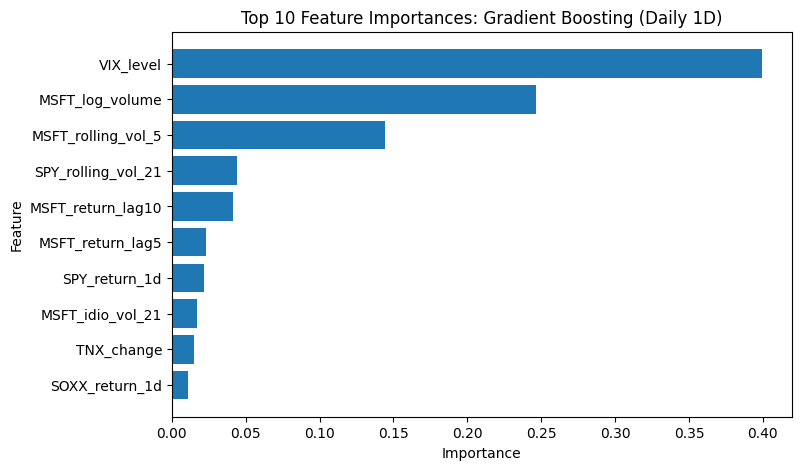

Top 10 Feature Importances for Weekly 5D:


,Feature,Importance
12,SPY_rolling_vol_5,0.486040
14,VIX_level,0.344324
26,MSFT_beta_SPY_60,0.120501
13,SPY_rolling_vol_21,0.038536
7,MSFT_rolling_vol_5,0.007989
21,TNX_level,0.002610
0,MSFT_return_1d,0.000000
23,SOXX_return_1d,0.000000
20,VIX_rolling_mean_21,0.000000
22,TNX_change,0.000000


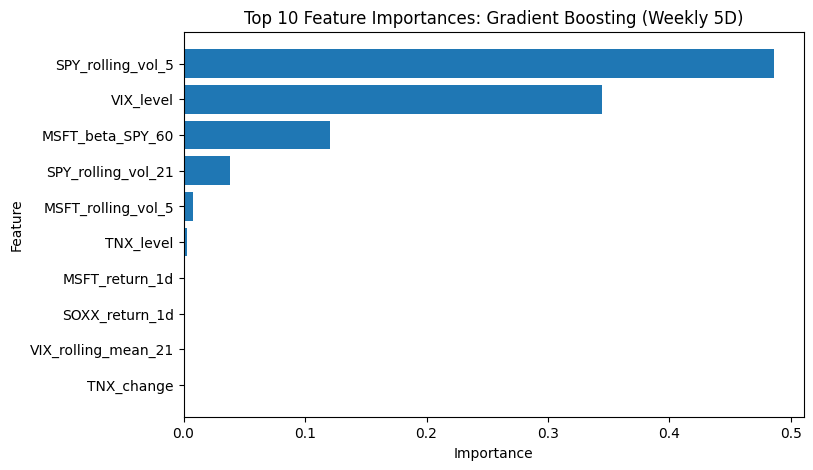

Top 10 Feature Importances for Monthly 21D:


,Feature,Importance
8,MSFT_rolling_vol_21,0.433099
12,SPY_rolling_vol_5,0.245645
14,VIX_level,0.201358
9,MSFT_log_volume,0.037193
19,MSFT_rolling_vol_63,0.030284
13,SPY_rolling_vol_21,0.026325
21,TNX_level,0.024100
20,VIX_rolling_mean_21,0.001998
25,TLT_rolling_vol_21,0.000000
26,MSFT_beta_SPY_60,0.000000


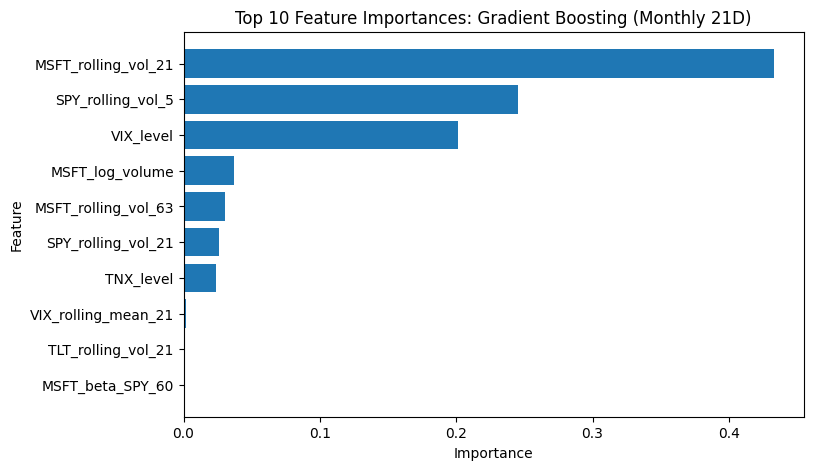

In [26]:
# Feature Importance for Best Gradient Boosting Models
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_dfs = {}

for horizon in horizon_order:
    
    model = best_gb_models[horizon]
    
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    feature_importance_dfs[horizon] = importance_df
    
    print(f"Top 10 Feature Importances for {horizon}:")
    display(importance_df.head(10))
    
    plt.figure(figsize=(8, 5))
    plt.barh(
        importance_df.head(10)['Feature'][::-1],
        importance_df.head(10)['Importance'][::-1]
    )
    plt.title(f'Top 10 Feature Importances: Gradient Boosting ({horizon})')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

Final Gradient Boosting Test Performance:


,Horizon,n_estimators,learning_rate,max_depth,Test MAE,Test RMSE,Test Normalized MAE,Test R2
0,Daily 1D,50,0.03,2,0.007398,0.010492,0.738324,0.042748
1,Weekly 5D,50,0.01,2,0.005956,0.008264,0.471741,-0.143132
2,Monthly 21D,50,0.01,2,0.004103,0.005255,0.298622,0.029032


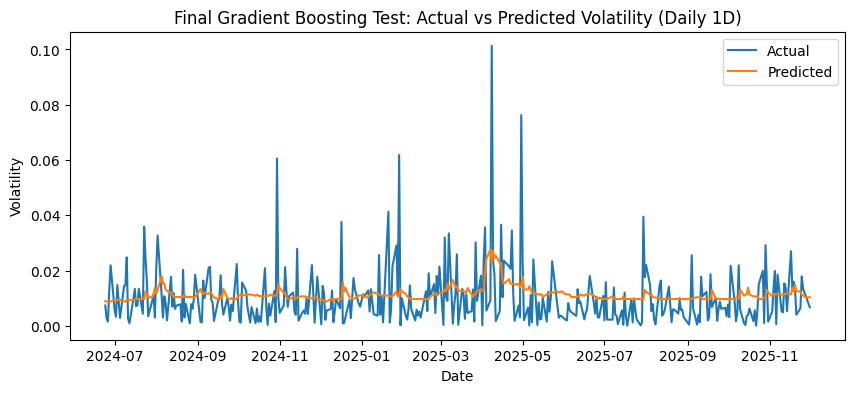

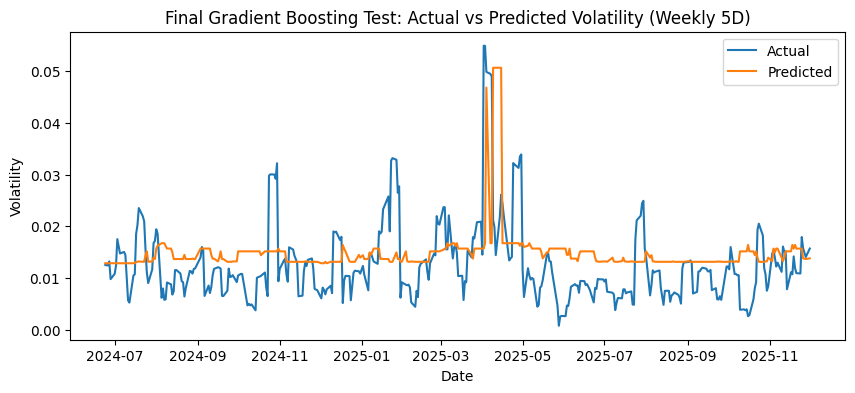

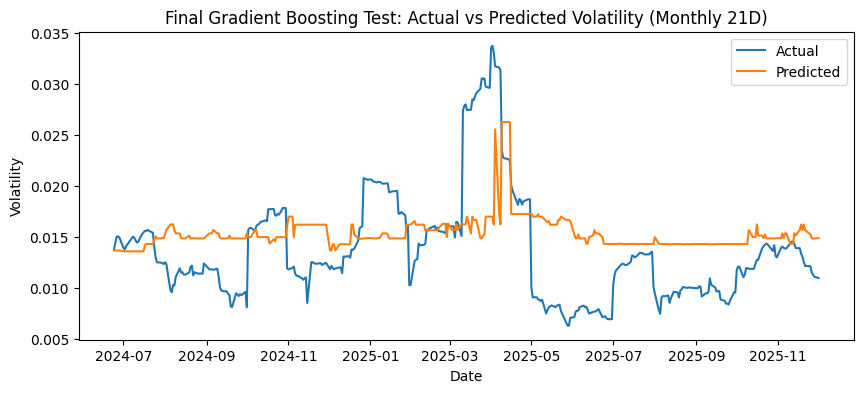

In [27]:

# Final Test Evaluation using Best Validation Parameters
from IPython.display import display

# Horizon order
horizon_order = ['Daily 1D', 'Weekly 5D', 'Monthly 21D']

targets_full = {
    'Daily 1D': (y_train_1d, y_valid_1d, y_test_1d),
    'Weekly 5D': (y_train_5d, y_valid_5d, y_test_5d),
    'Monthly 21D': (y_train_21d, y_valid_21d, y_test_21d)
}

# Combine train + validation features
X_train_valid = pd.concat([X_train, X_valid])

final_scaler = StandardScaler()

X_train_valid_scaled = final_scaler.fit_transform(X_train_valid)
X_test_scaled_final = final_scaler.transform(X_test)

X_train_valid_scaled = pd.DataFrame(
    X_train_valid_scaled,
    index=X_train_valid.index,
    columns=feature_cols
)

X_test_scaled_final = pd.DataFrame(
    X_test_scaled_final,
    index=X_test.index,
    columns=feature_cols
)


# Final model training and test evaluation
final_test_results = []
final_gb_models = {}
final_gb_test_predictions = {}

for _, row in best_params_by_horizon.iterrows():
    
    horizon = row['Horizon']
    
    y_train, y_valid, y_test = targets_full[horizon]
    
    y_train_valid = pd.concat([y_train, y_valid])
    
    final_model = GradientBoostingRegressor(
        n_estimators=int(row['n_estimators']),
        learning_rate=float(row['learning_rate']),
        max_depth=int(row['max_depth']),
        random_state=42
    )
    
    final_model.fit(X_train_valid_scaled, y_train_valid)
    
    # Predict on test set only
    y_test_pred = final_model.predict(X_test_scaled_final)
    
    # Test metrics
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    test_normalized_mae = test_mae / y_test.mean()
    
    final_test_results.append({
        'Horizon': horizon,
        'n_estimators': int(row['n_estimators']),
        'learning_rate': float(row['learning_rate']),
        'max_depth': int(row['max_depth']),
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test Normalized MAE': test_normalized_mae,
        'Test R2': test_r2
    })
    
    final_gb_models[horizon] = final_model
    final_gb_test_predictions[horizon] = y_test_pred


# Create final test results DataFrame
final_test_results_df = pd.DataFrame(final_test_results)

final_test_results_df['Horizon'] = pd.Categorical(
    final_test_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

final_test_results_df = (
    final_test_results_df
    .sort_values('Horizon')
    .reset_index(drop=True)
)

print("Final Gradient Boosting Test Performance:")
display(final_test_results_df)


# Test Actual vs Predicted Plots
for horizon in horizon_order:
    
    _, _, y_test = targets_full[horizon]
    y_test_pred = final_gb_test_predictions[horizon]
    
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, y_test_pred, label='Predicted')
    plt.title(f'Final Gradient Boosting Test: Actual vs Predicted Volatility ({horizon})')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend()
    plt.show()

## 4.4 Model 3: ___

**Implemented by: Shawn Wen** 

- Motivation
- Model description
- Why this method is appropriate


Repeat until Model N (N=your group size)


## 4.5 Model 4: Random Forest

**Implemented by: Zihan Zhu** 

- Motivation

Random Forest is chosen because future stock volatility may depend on complex interactions among market variables. Features such as VIX, SPY returns, QQQ returns, trading volume, lagged MSFT returns, and rolling volatility may influence future volatility in a nonlinear way. A simple linear model may not fully capture these relationships.

Random Forest is also robust to noisy financial data. By averaging predictions from many decision trees, it can reduce overfitting and improve prediction stability compared with a single decision tree.

- Model description

Random Forest is an ensemble learning method based on bagging. The model builds many decision trees using bootstrap samples of the training data. At each split, only a random subset of features is considered, which increases diversity among trees.

For a regression problem, the final prediction is the average prediction across all trees in the forest. In this project, we tune the main hyperparameters including the number of trees (n_estimators), maximum tree depth (max_depth), and minimum number of samples required in a leaf node (min_samples_leaf). The best parameter combination is selected using validation RMSE.

- Why this method is appropriate

Random Forest is appropriate because stock volatility often exhibits nonlinear behavior and interactions among market indicators. It can capture these patterns without requiring us to manually specify nonlinear terms or interaction effects.

The main assumption is that historical market information contains useful signals for future volatility prediction. We also split the data chronologically into training, validation, and test sets to avoid look-ahead bias. Since Random Forest is tree-based, feature scaling is not required, making it relatively robust to differences in feature magnitude.

Repeat until Model N (N=your group size)


In [28]:
# =========================
# Random Forest Hyperparameter Tuning
# =========================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd

horizon_order = ['Daily 1D', 'Weekly 5D', 'Monthly 21D']

targets = {
    'Daily 1D': (y_train_1d, y_valid_1d, y_test_1d),
    'Weekly 5D': (y_train_5d, y_valid_5d, y_test_5d),
    'Monthly 21D': (y_train_21d, y_valid_21d, y_test_21d)
}

param_grid = []

# -------------------------
# Round 1: Initial Search
# -------------------------

for n_estimators in [100, 200]:
    for max_depth in [3, 5, 8]:
        for min_samples_leaf in [3, 5, 10]:

            param_grid.append({
                'Search Round': 'Initial Search',
                'n_estimators': n_estimators,
                'max_depth': max_depth,
                'min_samples_leaf': min_samples_leaf
            })

# -------------------------
# Round 2: Refined Search
# -------------------------

for max_depth in [2, 3, 4, 5, 6]:
    for min_samples_leaf in [8, 10, 12]:

        param_grid.append({
            'Search Round': 'Refined Search',
            'n_estimators': 200,
            'max_depth': max_depth,
            'min_samples_leaf': min_samples_leaf
        })

rf_tuning_results = []

for horizon in horizon_order:

    y_train, y_valid, y_test = targets[horizon]

    for params in param_grid:

        model = RandomForestRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train_scaled, y_train)

        y_valid_pred = model.predict(X_valid_scaled)

        valid_mae = mean_absolute_error(
            y_valid,
            y_valid_pred
        )

        valid_rmse = np.sqrt(
            mean_squared_error(
                y_valid,
                y_valid_pred
            )
        )

        valid_r2 = r2_score(
            y_valid,
            y_valid_pred
        )

        rf_tuning_results.append({
            'Search Round': params['Search Round'],
            'Horizon': horizon,
            'n_estimators': params['n_estimators'],
            'max_depth': params['max_depth'],
            'min_samples_leaf': params['min_samples_leaf'],
            'Validation MAE': valid_mae,
            'Validation RMSE': valid_rmse,
            'Validation R2': valid_r2
        })

rf_tuning_results = pd.DataFrame(
    rf_tuning_results
)

rf_tuning_results.head()

,Search Round,Horizon,n_estimators,max_depth,min_samples_leaf,Validation MAE,Validation RMSE,Validation R2
0,Initial Search,Daily 1D,100,3,3,0.006924,0.009148,0.069240
1,Initial Search,Daily 1D,100,3,5,0.006918,0.009158,0.067192
2,Initial Search,Daily 1D,100,3,10,0.006894,0.009210,0.056582
3,Initial Search,Daily 1D,100,5,3,0.007310,0.009254,0.047441
4,Initial Search,Daily 1D,100,5,5,0.007148,0.009169,0.065040


In [29]:
# =========================
# Best Hyperparameters
# =========================

best_rf_params = (
    rf_tuning_results
    .sort_values('Validation RMSE')
    .groupby('Horizon')
    .head(1)
    .reset_index(drop=True)
)

best_rf_params

,Search Round,Horizon,n_estimators,max_depth,min_samples_leaf,Validation MAE,Validation RMSE,Validation R2
0,Refined Search,Monthly 21D,200,2,10,0.002667,0.003509,-0.111700
1,Initial Search,Weekly 5D,100,3,10,0.004567,0.006050,0.032068
2,Refined Search,Daily 1D,200,6,8,0.006978,0.009132,0.072568


In [30]:
# =========================
# Final Test Evaluation
# =========================

rf_test_results = []

rf_models = {}

rf_test_predictions = {}

X_train_valid_scaled = np.vstack([
    np.asarray(X_train_scaled),
    np.asarray(X_valid_scaled)
])

X_test_scaled_array = np.asarray(
    X_test_scaled
)

for _, row in best_rf_params.iterrows():

    horizon = row['Horizon']

    y_train, y_valid, y_test = targets[horizon]

    y_train_valid = pd.concat([
        y_train,
        y_valid
    ])

    final_rf = RandomForestRegressor(
        n_estimators=int(row['n_estimators']),
        max_depth=int(row['max_depth']),
        min_samples_leaf=int(row['min_samples_leaf']),
        random_state=42,
        n_jobs=-1
    )

    final_rf.fit(
        X_train_valid_scaled,
        y_train_valid
    )

    y_test_pred = final_rf.predict(
        X_test_scaled_array
    )

    test_mae = mean_absolute_error(
        y_test,
        y_test_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )

    baseline_pred = np.repeat(
        y_train_valid.mean(),
        len(y_test)
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            baseline_pred
        )
    )

    improvement = (
        baseline_rmse -
        test_rmse
    ) / baseline_rmse

    rf_test_results.append({
        'Horizon': horizon,
        'Search Round': row['Search Round'],
        'Best n_estimators': int(row['n_estimators']),
        'Best max_depth': int(row['max_depth']),
        'Best min_samples_leaf': int(row['min_samples_leaf']),
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test R2': test_r2,
        'Baseline RMSE': baseline_rmse,
        'Improvement over Baseline': improvement
    })

    rf_models[horizon] = final_rf

    rf_test_predictions[horizon] = y_test_pred

rf_summary = pd.DataFrame(
    rf_test_results
)

rf_summary.round(4)

,Horizon,Search Round,Best n_estimators,Best max_depth,Best min_samples_leaf,Test MAE,Test RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,Monthly 21D,Refined Search,200,2,10,0.0043,0.0057,-0.1530,0.0056,-0.0260
1,Weekly 5D,Initial Search,100,3,10,0.0063,0.0091,-0.3830,0.0080,-0.1415
2,Daily 1D,Refined Search,200,6,8,0.0077,0.0108,-0.0059,0.0109,0.0115


In [31]:
# =========================
# Deep Tree Check
# =========================

deep_check_grid = [
    {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 10},
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 10},
    {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 10},
]

deep_check_results = []

for horizon in horizon_order:

    y_train, y_valid, y_test = targets[horizon]

    for params in deep_check_grid:

        model = RandomForestRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train_scaled, y_train)

        y_valid_pred = model.predict(X_valid_scaled)

        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)

        deep_check_results.append({
            'Horizon': horizon,
            'n_estimators': params['n_estimators'],
            'max_depth': params['max_depth'],
            'min_samples_leaf': params['min_samples_leaf'],
            'Validation MAE': valid_mae,
            'Validation RMSE': valid_rmse,
            'Validation R2': valid_r2
        })

deep_check_results = pd.DataFrame(deep_check_results)

deep_check_results.sort_values(
    ['Horizon', 'Validation RMSE']
)

,Horizon,n_estimators,max_depth,min_samples_leaf,Validation MAE,Validation RMSE,Validation R2
1,Daily 1D,100,10,10,0.007027,0.009131,0.072679
2,Daily 1D,100,12,10,0.007025,0.009132,0.072541
0,Daily 1D,100,8,10,0.007009,0.009139,0.071003
8,Monthly 21D,100,12,10,0.004612,0.005481,-1.712525
6,Monthly 21D,100,8,10,0.004659,0.005526,-1.757767
7,Monthly 21D,100,10,10,0.004673,0.005552,-1.783054
3,Weekly 5D,100,8,10,0.005384,0.007127,-0.343191
4,Weekly 5D,100,10,10,0.005389,0.007143,-0.349414
5,Weekly 5D,100,12,10,0.005394,0.007147,-0.350670


In [32]:
# =========================
# Feature Importance Tables
# =========================

for horizon in horizon_order:

    model = rf_models[horizon]

    importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    })

    importance = (
        importance
        .sort_values(
            'Importance',
            ascending=False
        )
    )

    print("\n")
    print("=" * 60)
    print(horizon)
    print("=" * 60)

    display(
        importance.head(15)
    )



Daily 1D


,Feature,Importance
14,VIX_level,0.399079
7,MSFT_rolling_vol_5,0.080239
9,MSFT_log_volume,0.080019
12,SPY_rolling_vol_5,0.072217
13,SPY_rolling_vol_21,0.027093
4,MSFT_return_lag10,0.026658
11,SPY_return_lag1,0.024859
21,TNX_level,0.023387
10,SPY_return_1d,0.021528
24,TLT_return_1d,0.016912




Weekly 5D


,Feature,Importance
14,VIX_level,0.453868
12,SPY_rolling_vol_5,0.374858
7,MSFT_rolling_vol_5,0.130033
21,TNX_level,0.010010
9,MSFT_log_volume,0.009234
13,SPY_rolling_vol_21,0.007969
20,VIX_rolling_mean_21,0.004101
25,TLT_rolling_vol_21,0.003058
8,MSFT_rolling_vol_21,0.001831
28,MSFT_idio_vol_21,0.001574




Monthly 21D


,Feature,Importance
8,MSFT_rolling_vol_21,0.366139
14,VIX_level,0.246191
12,SPY_rolling_vol_5,0.236324
9,MSFT_log_volume,0.068803
7,MSFT_rolling_vol_5,0.049351
20,VIX_rolling_mean_21,0.019930
13,SPY_rolling_vol_21,0.007256
28,MSFT_idio_vol_21,0.002217
19,MSFT_rolling_vol_63,0.001939
4,MSFT_return_lag10,0.000699


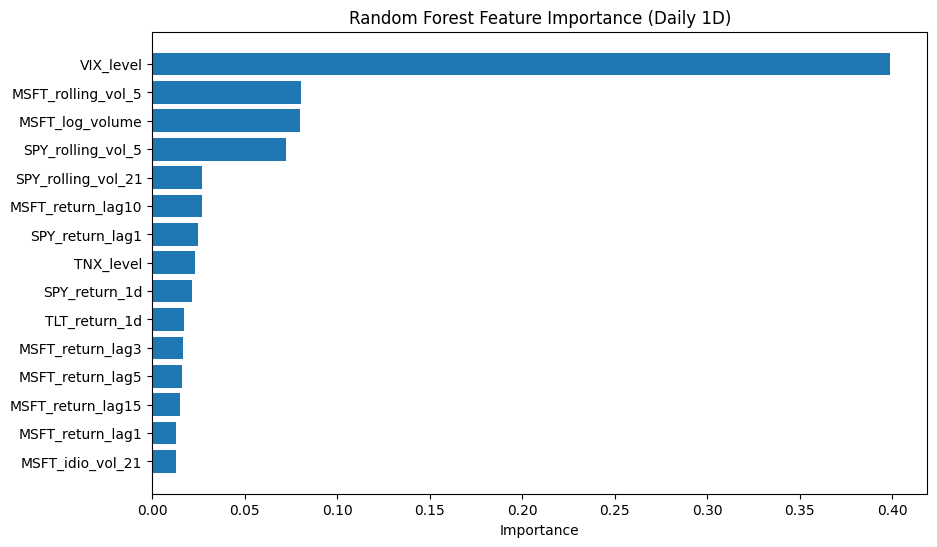

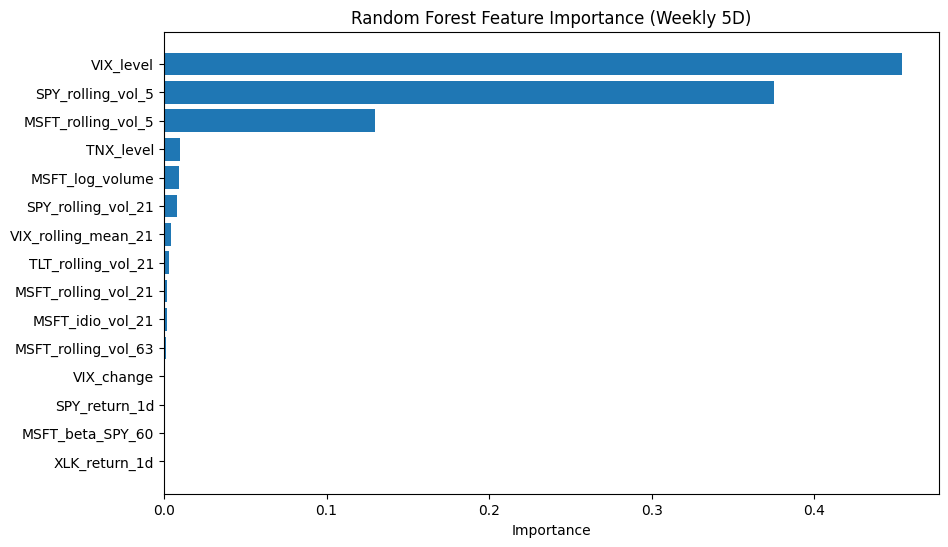

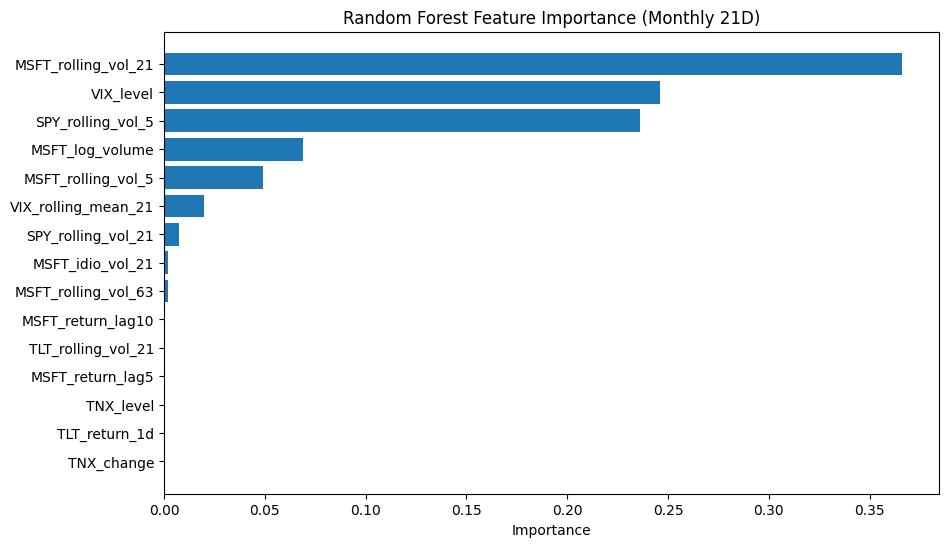

In [33]:
# =========================
# Feature Importance Plot
# =========================

for horizon in horizon_order:

    model = rf_models[horizon]

    importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    })

    importance = (
        importance
        .sort_values(
            'Importance',
            ascending=False
        )
        .head(15)
    )

    plt.figure(figsize=(10,6))

    plt.barh(
        importance['Feature'],
        importance['Importance']
    )

    plt.gca().invert_yaxis()

    plt.title(
        f'Random Forest Feature Importance ({horizon})'
    )

    plt.xlabel('Importance')

    plt.show()

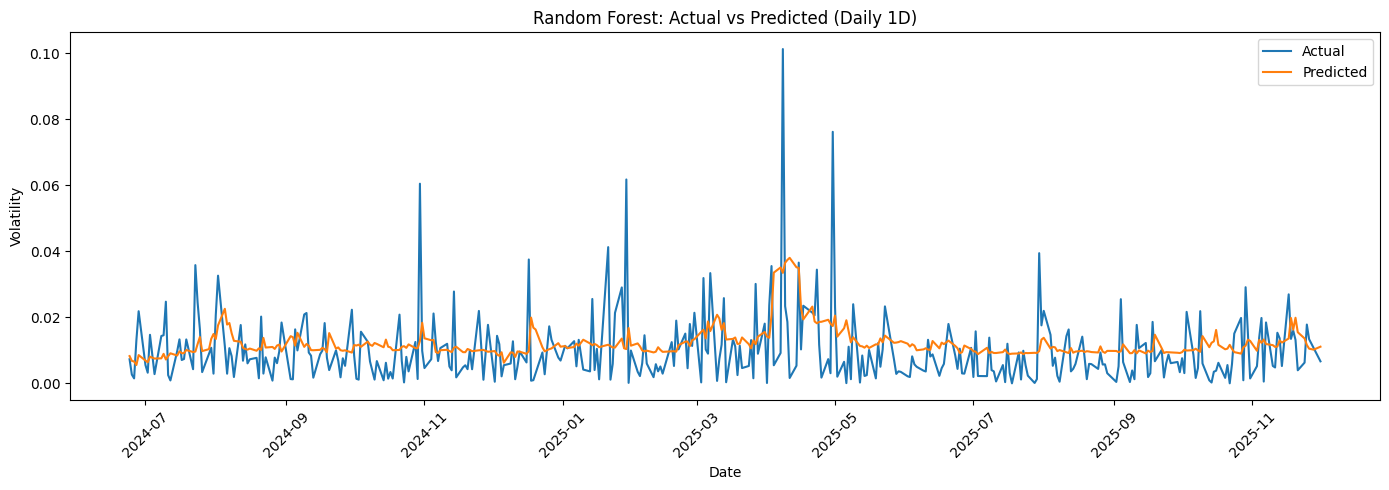

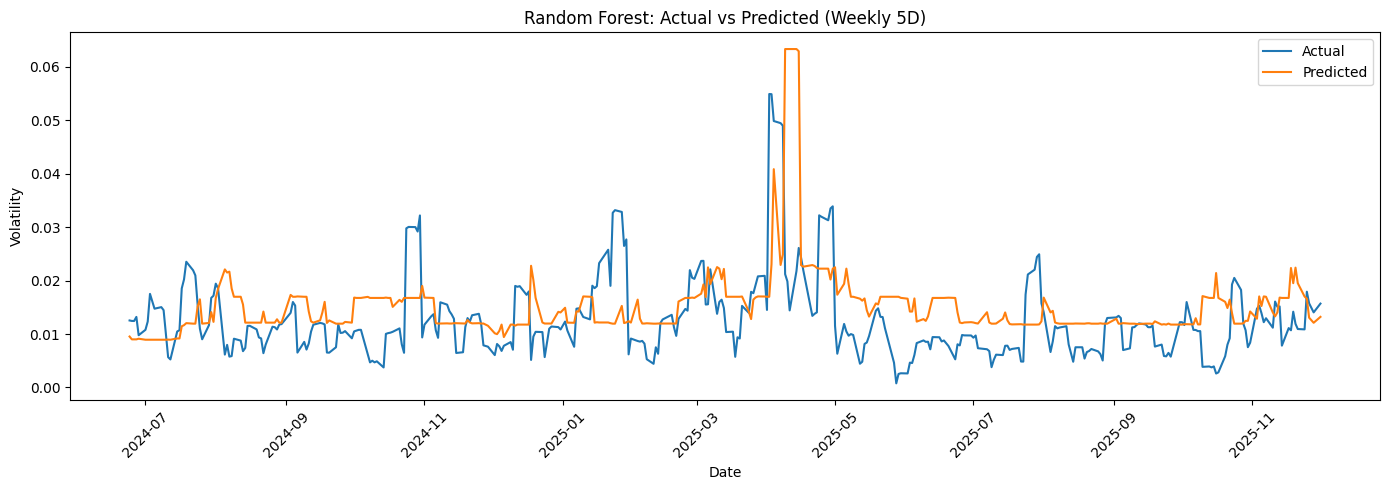

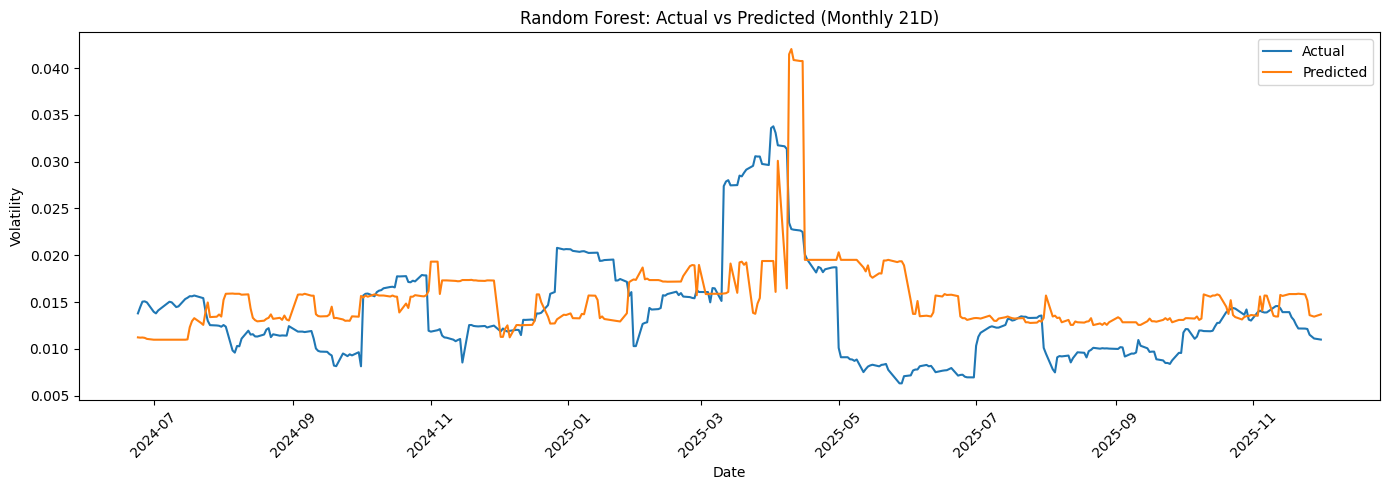

In [34]:
# =========================
# Actual vs Predicted
# =========================

for horizon in horizon_order:

    y_train, y_valid, y_test = targets[horizon]

    y_test_pred = rf_test_predictions[horizon]

    plt.figure(figsize=(14,5))

    plt.plot(
        y_test.index,
        y_test.values,
        label='Actual'
    )

    plt.plot(
        y_test.index,
        y_test_pred,
        label='Predicted'
    )

    plt.title(
        f'Random Forest: Actual vs Predicted ({horizon})'
    )

    plt.xlabel('Date')
    plt.ylabel('Volatility')

    plt.xticks(rotation=45)

    plt.legend()

    plt.tight_layout()

    plt.show()

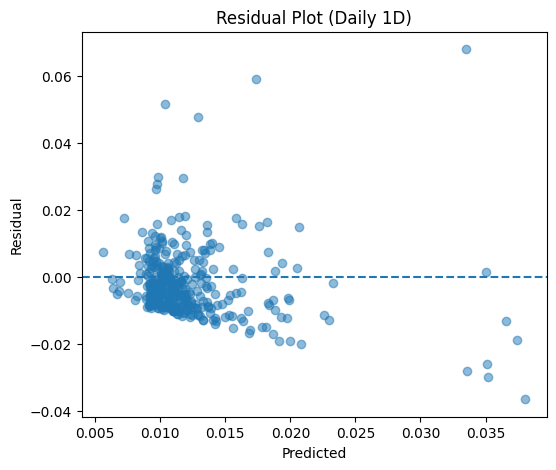

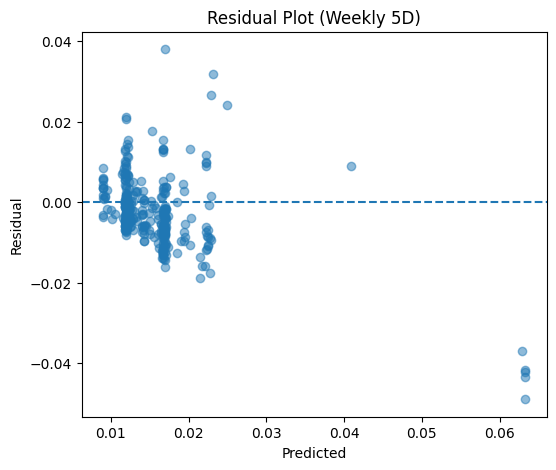

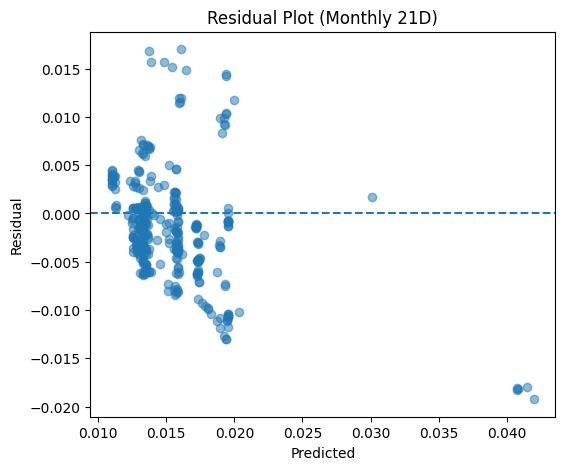

In [35]:
# =========================
# Residual Plot
# =========================

for horizon in horizon_order:

    y_train, y_valid, y_test = targets[horizon]

    y_test_pred = rf_test_predictions[horizon]

    residuals = (
        y_test -
        y_test_pred
    )

    plt.figure(figsize=(6,5))

    plt.scatter(
        y_test_pred,
        residuals,
        alpha=0.5
    )

    plt.axhline(
        y=0,
        linestyle='--'
    )

    plt.xlabel('Predicted')

    plt.ylabel('Residual')

    plt.title(
        f'Residual Plot ({horizon})'
    )

    plt.show()

In [36]:
# Compare current best RF parameters with deep tree check

current_best = best_rf_params[
    [
        'Horizon',
        'Search Round',
        'n_estimators',
        'max_depth',
        'min_samples_leaf',
        'Validation RMSE',
        'Validation R2'
    ]
].copy()

current_best['Model Type'] = 'Selected Shallow RF'

deep_best = (
    deep_check_results
    .sort_values('Validation RMSE')
    .groupby('Horizon')
    .head(1)
    .reset_index(drop=True)
)

deep_best['Search Round'] = 'Deep Tree Check'
deep_best['Model Type'] = 'Deep RF'

comparison = pd.concat([
    current_best,
    deep_best[
        [
            'Horizon',
            'Search Round',
            'n_estimators',
            'max_depth',
            'min_samples_leaf',
            'Validation RMSE',
            'Validation R2',
            'Model Type'
        ]
    ]
])

comparison.sort_values(
    ['Horizon', 'Validation RMSE']
)

,Horizon,Search Round,n_estimators,max_depth,min_samples_leaf,Validation RMSE,Validation R2,Model Type
2,Daily 1D,Deep Tree Check,100,10,10,0.009131,0.072679,Deep RF
2,Daily 1D,Refined Search,200,6,8,0.009132,0.072568,Selected Shallow RF
0,Monthly 21D,Refined Search,200,2,10,0.003509,-0.111700,Selected Shallow RF
0,Monthly 21D,Deep Tree Check,100,12,10,0.005481,-1.712525,Deep RF
1,Weekly 5D,Initial Search,100,3,10,0.006050,0.032068,Selected Shallow RF
1,Weekly 5D,Deep Tree Check,100,8,10,0.007127,-0.343191,Deep RF


# 5. Results

Clearly separate the presentation of results from the conclusions.

## 5.1 Evaluation Metrics
- Explain why the chosen metrics are appropriate.

## 5.2 Main Quantitative Results
- Present results in tables. Compare model performance after tuning.


## 5.3 Visualizations
- Prediction vs actual
- Residual plots
- Feature importance
- Confusion matrix or ROC curve if classification


# 6. Discussions and Conclusions

Make it brief; (2-3 paragraphs max)

Discuss:
- Which model performed best?
- Why do you think it performed best?
- What do the results mean in the financial context?
- Are there economic or practical implications?
- What are the limitations of the study?

Conclude:
- Summarize the main findings.
- State the major takeaway.
- Suggest possible future work.

# Appendix. Reproducibility

- State the software environment.
- State package versions if relevant.
- Explain how to reproduce the analysis.
- Ensure the notebook has been run from start to finish.


In [37]:
# example: package versions
# import sys
# print(sys.version)
# print(pd.__version__)
# print(np.__version__)

# References

- Include all papers, datasets, websites, and software packages cited in the notebook.
- Use a consistent citation style.
